In [12]:
# Подключение Google Drive
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=False)

PROJECT_DIR = '/content/drive/MyDrive/РУДН/ВКР/ВКР_практика_финал_2'
os.chdir(PROJECT_DIR)

for d in ['checkpoints', 'results', 'figures']:
    os.makedirs(d, exist_ok=True)

print(f'Рабочая директория: {os.getcwd()}')
print('Содержимое:', sorted(os.listdir('.')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Рабочая директория: /content/drive/MyDrive/РУДН/ВКР/ВКР_практика_финал_2
Содержимое: ['checkpoints', 'figures', 'results', 'Копия Копия_Копия_ВКР_финал_2.ipynb']


In [13]:
# Импорты и фиксация seed
import math, time, json, warnings, gc
from typing import Tuple, Dict, Optional

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats, optimize
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'Устройство: {DEVICE}')
print(f'Seed: {SEED}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
Seed: 42
GPU: Tesla T4


In [14]:
# Конфигурация гиперпараметров

# Портфель
TICKERS = ['SBER', 'LKOH', 'GAZP']
WEIGHTS = np.array([0.40, 0.35, 0.25])
assert abs(WEIGHTS.sum() - 1.0) < 1e-9

START_DATE = '2015-01-01'
END_DATE   = '2024-12-31'
TRAIN_END  = '2021-12-31'
TEST_START = '2022-01-01'

CACHE_PRICES  = 'cache_prices.csv'
CACHE_RETURNS = 'cache_returns_tr.csv'

# Диффузионный процесс
# T=50: для одномерного ряда достаточно; косинусное расписание даёт
# alpha_bar_{T/4}=0.836 — сигнал данных значим на первых 12 шагах диффузии
T_DIFF = 50
S_COSINE = 0.008   # параметр смещения (Nichol & Dhariwal, 2021)
X0_CLIP  = 10.0    # клиппинг в нормализованном пространстве: +-10 sigma

# Архитектура трансформера
W = 30    # ширина контекстного окна, обоснована ARCH-эффектом
D_MODEL = 64
N_HEADS = 4     # d_model / N_heads = 16
N_LAYERS = 3
D_FF = 256   # 4 * d_model, стандарт Vaswani et al. (2017)
DROPOUT = 0.1

# Обучение
LR = 3e-4
BATCH_SIZE = 64
MAX_EPOCHS = 150
PATIENCE = 25   # по сглаженному MA-5 val_loss

# Риск-метрики
ALPHA = 0.99   # уровень доверия VaR/ES, стандарт Basel III
N_SCENARIOS = 1000   # число генерируемых сценариев
WINDOW_BT = 250    # скользящее окно baseline моделей (1 торговый год)
BACKTEST_STEP = 1      # шаг бэктеста: 744 наблюдения

# Пути к чекпоинтам
CKPT = {
    'tr_huber05': 'checkpoints/transformer_huber05.pt',
    'tr_mse':     'checkpoints/transformer_mse.pt',
    'tr_huber15': 'checkpoints/transformer_huber15.pt',
    'tr_huber25': 'checkpoints/transformer_huber25.pt',
    'mlp_mse':    'checkpoints/mlp_mse.pt',
    'backtest':   'checkpoints/backtest_main.json',
}

print('Конфигурация загружена')
print(f'  T={T_DIFF}, W={W}, d={D_MODEL}, H={N_HEADS}, L={N_LAYERS}')
print(f'  alpha={ALPHA}, N_scenarios={N_SCENARIOS}, backtest_step={BACKTEST_STEP}')

Конфигурация загружена
  T=50, W=30, d=64, H=4, L=3
  alpha=0.99, N_scenarios=1000, backtest_step=1


In [15]:
# Загрузка данных с MOEX ISS API

def fetch_ticker_moex(ticker: str, start: str, end: str) -> pd.Series:
    """Загрузка дневных цен закрытия с MOEX ISS API (пагинация, retry)."""
    base = ('https://iss.moex.com/iss/history/engines/stock/'
            'markets/shares/boards/TQBR/securities')
    records, offset = [], 0
    while True:
        url = (f'{base}/{ticker}.json?from={start}&till={end}'
               f'&limit=100&start={offset}')
        for attempt in range(3):
            try:
                r = requests.get(url, timeout=30)
                r.raise_for_status()
                break
            except Exception:
                time.sleep(2 ** attempt)
        else:
            raise RuntimeError(f'Не удалось загрузить {ticker} после 3 попыток')
        data = r.json()['history']
        rows = data['data']
        if not rows:
            break
        records.extend(rows)
        offset += len(rows)
        if len(rows) < 100:
            break
        time.sleep(0.15)
    df = (pd.DataFrame(records, columns=data['columns'])
          [['TRADEDATE', 'CLOSE']]
          .assign(TRADEDATE=lambda x: pd.to_datetime(x['TRADEDATE']))
          .dropna(subset=['CLOSE'])
          .drop_duplicates('TRADEDATE')
          .set_index('TRADEDATE').sort_index())
    return df['CLOSE'].rename(ticker)


def fetch_dividends_moex(ticker: str) -> pd.Series:
    """Загрузка истории дивидендов по дате закрытия реестра."""
    url = f'https://iss.moex.com/iss/securities/{ticker}/dividends.json'
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        data = r.json()['dividends']
        df   = pd.DataFrame(data['data'], columns=data['columns'])
        if df.empty or 'registryclosedate' not in df.columns:
            return pd.Series(dtype=float, name=ticker)
        df['registryclosedate'] = pd.to_datetime(
            df['registryclosedate'], errors='coerce')
        df = df.dropna(subset=['registryclosedate', 'value'])
        return (df.set_index('registryclosedate')['value']
                .rename(ticker).astype(float))
    except Exception as e:
        print(f'  [warn] Дивиденды {ticker}: {e}')
        return pd.Series(dtype=float, name=ticker)


def build_total_return(prices: pd.DataFrame, divs: dict) -> pd.DataFrame:
    """
    Логарифмические total return доходности с дивидендной корректировкой.

    Методология:
      Экс-дивидендная дата = дата закрытия реестра - 2 рабочих дня (T+2, MOEX).
      P_tilde(t_ex) = P(t_ex) + D, тогда r(t_ex) = log(P_tilde / P(t_ex-1)) ~ 0.
      Экономически корректно: ценовое падение компенсируется дивидендом.
    """
    tr_returns = {}
    for ticker in prices.columns:
        p = prices[ticker].copy()
        d = divs.get(ticker, pd.Series(dtype=float))
        applied = 0
        for record_date, div_val in d.items():
            if pd.isna(div_val) or div_val <= 0:
                continue
            ex_date    = record_date - pd.offsets.BDay(2)
            candidates = p.index[p.index >= ex_date]
            if len(candidates) == 0:
                continue
            actual_ex = candidates[0]
            if (actual_ex - ex_date).days > 5:
                continue
            p.loc[actual_ex] += div_val
            applied += 1
        print(f'  {ticker}: применено дивидендов = {applied}')
        tr_returns[ticker] = np.log(p / prices[ticker].shift(1)).dropna()
    return pd.DataFrame(tr_returns).dropna()


def load_portfolio(use_cache: bool = True) -> pd.Series:
    """Загрузка или вычисление взвешенных портфельных доходностей."""
    if use_cache and os.path.exists(CACHE_RETURNS):
        print(f'[data] Кэш: {CACHE_RETURNS}')
        return pd.read_csv(CACHE_RETURNS, index_col=0, parse_dates=True).squeeze()
    print('[data] Загрузка цен с MOEX ISS...')
    prices = {}
    for t in TICKERS:
        print(f'  {t}', end=' ', flush=True)
        prices[t] = fetch_ticker_moex(t, START_DATE, END_DATE)
        print(f'({len(prices[t])} дней)')
    price_df = pd.DataFrame(prices).dropna()
    price_df.to_csv(CACHE_PRICES)
    print('[data] Загрузка дивидендов...')
    divs    = {t: fetch_dividends_moex(t) for t in TICKERS}
    log_ret = build_total_return(price_df, divs)
    portfolio = (log_ret[TICKERS] @ WEIGHTS).rename('portfolio_return')
    portfolio.to_csv(CACHE_RETURNS)
    print(f'[data] Сохранено {len(portfolio)} наблюдений')
    return portfolio


portfolio_returns = load_portfolio(use_cache=True)

train_s   = portfolio_returns[portfolio_returns.index <= TRAIN_END]
test_s    = portfolio_returns[portfolio_returns.index >= TEST_START]
train_arr = train_s.values.astype(np.float64)
test_arr  = test_s.values.astype(np.float64)
all_arr   = np.concatenate([train_arr, test_arr])
n_train   = len(train_arr)
n_test    = len(test_arr)

# Нормализация по параметрам train-выборки (защита от утечки данных)
MU  = float(train_arr.mean())
STD = float(train_arr.std(ddof=1))
train_scaled = (train_arr - MU) / STD

print(f'\nTrain: {n_train} дней ({train_s.index[0].date()} - {train_s.index[-1].date()})')
print(f'Test:  {n_test} дней  ({test_s.index[0].date()} - {test_s.index[-1].date()})')
print(f'MU={MU*100:.4f}%, STD={STD*100:.4f}%')
print(f'Сдвиг волатильности: sigma_test/sigma_train = {test_arr.std(ddof=1)/STD:.3f}')

[data] Загрузка цен с MOEX ISS...
  SBER (2509 дней)
  LKOH (2509 дней)
  GAZP (2509 дней)
[data] Загрузка дивидендов...
  SBER: применено дивидендов = 5
  LKOH: применено дивидендов = 21
  GAZP: применено дивидендов = 9
[data] Сохранено 2508 наблюдений

Train: 1764 дней (2015-01-06 - 2021-12-30)
Test:  744 дней  (2022-01-03 - 2024-12-30)
MU=0.0922%, STD=1.5018%
Сдвиг волатильности: sigma_test/sigma_train = 1.556


In [16]:
# Dataset и DataLoader

class ReturnWindowDataset(Dataset):
    """
    Скользящие окна нормализованных доходностей для обучения DDPM.

    Каждый пример: контекст (W,) и цель (1,).
    Контекст c_t = (r_tilde_{t-W}, ..., r_tilde_{t-1}).
    Цель x_0 = r_tilde_t — значение, которое будет зашумлено в прямом процессе.
    """
    def __init__(self, arr: np.ndarray, w: int = W):
        self.arr = torch.tensor(arr, dtype=torch.float32)
        self.w = w

    def __len__(self) -> int:
        return len(self.arr) - self.w

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        ctx = self.arr[idx:idx + self.w]
        x0  = self.arr[idx + self.w:idx + self.w + 1]
        return ctx, x0


# Временной сплит: последние 10% train-периода образуют val-выборку.
# Такой порядок честнее для временных рядов: val следует за train хронологически.
n_val = int(len(train_scaled) * 0.10)
n_tr  = len(train_scaled) - n_val

ds_tr = ReturnWindowDataset(train_scaled[:n_tr])
ds_val = ReturnWindowDataset(train_scaled[n_tr:])

g_fix = torch.Generator().manual_seed(SEED)
dl_tr = DataLoader(ds_tr,  batch_size=BATCH_SIZE, shuffle=True,  generator=g_fix)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)

print(f'train: {len(ds_tr)} окон, val: {len(ds_val)} окон')
print(f'батчей train: {len(dl_tr)}, val: {len(dl_val)}')

train: 1558 окон, val: 146 окон
батчей train: 25, val: 3


In [17]:
# Статистический анализ (Таблица 2)
print()
print('Раздел 3.1. Статистический анализ эмпирической базы')

rows_desc = []
for label, arr in [('Train 2015-2021', train_arr), ('Test  2022-2024', test_arr)]:
    jb_s, jb_p = stats.jarque_bera(arr)
    rows_desc.append({
        'Выборка': label,
        'N':       len(arr),
        'Mean,%':  round(arr.mean() * 100, 4),
        'Std,%':   round(arr.std(ddof=1) * 100, 4),
        'Skew':    round(float(stats.skew(arr)), 3),
        'Kurt':    round(float(stats.kurtosis(arr)), 3),
        'Min,%':   round(arr.min() * 100, 2),
        'Max,%':   round(arr.max() * 100, 2),
        'JB p':    f'{jb_p:.2e}',
    })
desc_df = pd.DataFrame(rows_desc)
print('\nТаблица 2. Описательная статистика портфельных доходностей')
print(desc_df.to_string(index=False))
desc_df.to_csv('results/table2_descriptive.csv', index=False, encoding='utf-8-sig')

# Тест Льюнга-Бокса: обоснование ширины контекстного окна W=30.
# Отсутствие автокорреляции r_t и наличие ARCH-эффекта в r^2_t
# подтверждают, что контекст несёт предиктивную информацию о волатильности.
print('\nТест Льюнга-Бокса (train):')
print(f'  {"Лаг":>4}  {"r_t (p-value)":>14}  {"r^2_t (p-value)":>16}')
lb_rows = []
for lag in [5, 10, 20]:
    p_r  = acorr_ljungbox(train_arr,    lags=lag, return_df=True)['lb_pvalue'].iloc[-1]
    p_r2 = acorr_ljungbox(train_arr**2, lags=lag, return_df=True)['lb_pvalue'].iloc[-1]
    print(f'  {lag:4d}  {p_r:14.4f}  {p_r2:16.4e}')
    lb_rows.append({'lag': lag, 'p_r': p_r, 'p_r2': p_r2})
pd.DataFrame(lb_rows).to_csv('results/table2_ljungbox.csv', index=False, encoding='utf-8-sig')

# Тесты стационарности
if os.path.exists(CACHE_PRICES):
    price_df_c = pd.read_csv(CACHE_PRICES, index_col=0, parse_dates=True)
    sber_p = price_df_c['SBER'].dropna()
    adf_p_val, p_adf_p, *_ = adfuller(sber_p,    autolag='AIC')
    adf_r_val, p_adf_r, *_ = adfuller(train_arr, autolag='AIC')
    _, p_kpss_r, *_         = kpss(train_arr, regression='c', nlags='auto')
    print(f'\nАDF (цены SBER):   stat={adf_p_val:.3f}, p={p_adf_p:.4f}')
    print(f'АDF (доходности):  stat={adf_r_val:.3f}, p={p_adf_r:.4f}')
    print(f'KPSS (доходности): p={p_kpss_r:.4f}')


Раздел 3.1. Статистический анализ эмпирической базы

Таблица 2. Описательная статистика портфельных доходностей
        Выборка    N  Mean,%  Std,%   Skew   Kurt  Min,%  Max,%     JB p
Train 2015-2021 1764  0.0922 1.5018 -0.548  8.221 -13.20   9.58 0.00e+00
Test  2022-2024  744  0.0151 2.3370 -5.019 71.344 -34.78   9.00 0.00e+00

Тест Льюнга-Бокса (train):
   Лаг   r_t (p-value)   r^2_t (p-value)
     5          0.0434        1.1040e-41
    10          0.2218        9.0174e-89
    20          0.4598        2.6509e-88

АDF (цены SBER):   stat=-2.029, p=0.2741
АDF (доходности):  stat=-20.249, p=0.0000
KPSS (доходности): p=0.1000


In [18]:
# Архитектуры нейронных сетей

class TransformerDenoiser(nn.Module):
    """
    Pre-LN Transformer денойзер eps_theta(x_t, t, c_t).

    Входная последовательность: [c_{t-W}, ..., c_{t-1}, x_t] — W+1 токенов.
    Каждый токен проецируется через Linear(1 -> d_model).
    К проекциям добавляется фиксированное синусоидальное позиционное кодирование.
    Эмбеддинг шага диффузии добавляется только к токену x_t (последний в seq).
    Выход: скалярная оценка добавленного шума eps_hat (epsilon-prediction).

    Выбор Pre-LN (norm_first=True) обеспечивает устойчивость градиентного
    потока при малой глубине (L=3) и малом объёме обучающей выборки.
    Transformer выбран вместо U-Net, поскольку механизм attention напрямую
    моделирует нелокальные зависимости в окне W, что соответствует природе
    ARCH-эффекта в финансовых временных рядах.
    """
    def __init__(self,
                 d_model:     int   = D_MODEL,
                 n_heads:     int   = N_HEADS,
                 n_layers:    int   = N_LAYERS,
                 d_ff:        int   = D_FF,
                 context_len: int   = W,
                 T:           int   = T_DIFF,
                 dropout:     float = DROPOUT):
        super().__init__()
        self.context_len = context_len
        self.token_proj  = nn.Linear(1, d_model)
        self.step_emb    = nn.Embedding(T, d_model)
        self.register_buffer('pos_enc', self._make_pos_enc(context_len + 1, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    @staticmethod
    def _make_pos_enc(seq_len: int, d: int) -> torch.Tensor:
        """Синусоидальное позиционное кодирование (Vaswani et al., 2017)."""
        pe  = torch.zeros(seq_len, d)
        pos = torch.arange(seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)

    def forward(self, xt: torch.Tensor, t: torch.Tensor,
                context: torch.Tensor) -> torch.Tensor:
        """
        Args:
            xt:      (B, 1) — зашумлённое значение x_t
            t:       (B,)   — индекс шага диффузии
            context: (B, W) — нормализованный контекст c_t
        Returns:
            (B, 1) — предсказанный шум eps_hat
        """
        seq    = torch.cat([context, xt], dim=1).unsqueeze(-1)
        tokens = self.token_proj(seq) + self.pos_enc
        tokens[:, -1, :] = tokens[:, -1, :] + self.step_emb(t)
        out = self.transformer(tokens)
        return self.head(out[:, -1, :])


class MLPDenoiser(nn.Module):
    """
    MLP-денойзер без контекстного окна — baseline для ablation study A.

    Намеренно игнорирует c_t: сравнение с TransformerDenoiser позволяет
    оценить вклад контекстного окна (ARCH-информации) в качество модели.
    Три скрытых слоя по 256 нейронов с активацией SiLU и LayerNorm.
    """
    def __init__(self, T: int = T_DIFF, hidden: int = 256):
        super().__init__()
        self.step_emb = nn.Embedding(T, hidden)
        self.net = nn.Sequential(
            nn.Linear(1 + hidden, hidden), nn.SiLU(), nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),     nn.SiLU(), nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),     nn.SiLU(), nn.LayerNorm(hidden),
            nn.Linear(hidden, 1))

    def forward(self, xt: torch.Tensor, t: torch.Tensor,
                context: torch.Tensor) -> torch.Tensor:
        emb = self.step_emb(t)
        inp = torch.cat([xt, emb], dim=-1)
        return self.net(inp)


n_params_tr  = sum(p.numel() for p in TransformerDenoiser().parameters() if p.requires_grad)
n_params_mlp = sum(p.numel() for p in MLPDenoiser().parameters()         if p.requires_grad)
print(f'TransformerDenoiser: {n_params_tr:,} параметров')
print(f'MLPDenoiser:         {n_params_mlp:,} параметров')

TransformerDenoiser: 153,473 параметров
MLPDenoiser:         212,225 параметров


In [19]:
# Планировщик шума (CosineNoiseScheduler)

class CosineNoiseScheduler:
    """
    DDPM с косинусным расписанием шума (Nichol & Dhariwal, 2021).

    Косинусное расписание: alpha_bar_t = f(t)/f(0),
    f(t) = cos^2((t/T + s) / (1 + s) * pi/2), s = 0.008.

    При T=50 значения: alpha_bar_{T/4}=0.836, alpha_bar_{T/2}=0.463.
    Сравнение с линейным расписанием (T=200): alpha_bar_{T/4} ~ 0.13.
    Косинусное расписание сохраняет предиктивную информацию контекста
    на большей доле шагов диффузии, что важно для финансовых рядов.

    Прямой процесс: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps.
    Клиппинг x_hat_0 в [-X0_CLIP, X0_CLIP] устраняет числовые взрывы при
    alpha_bar_t -> 0, не ограничивая реальные стресс-сценарии
    (исторический минимум = -8.76 sigma < 10 sigma).
    """
    def __init__(self, T: int = T_DIFF, s: float = S_COSINE, device: str = DEVICE):
        self.T      = T
        self.device = device
        t_grid = torch.linspace(0, T, T + 1, device=device)
        f_t    = torch.cos((t_grid / T + s) / (1 + s) * math.pi / 2) ** 2
        ab     = (f_t / f_t[0])[1:]
        ab_prev = torch.cat([torch.ones(1, device=device), ab[:-1]])
        betas   = (1 - ab / ab_prev).clamp(max=0.999)
        self.betas         = betas
        self.alphas        = 1.0 - betas
        self.ab            = ab
        self.sqrt_ab       = ab.sqrt()
        self.sqrt_one_m_ab = (1.0 - ab).sqrt()

    def add_noise(self, x0: torch.Tensor,
                  t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Прямой процесс: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*eps."""
        eps = torch.randn_like(x0)
        xt  = self.sqrt_ab[t].view(-1, 1) * x0 + self.sqrt_one_m_ab[t].view(-1, 1) * eps
        return xt, eps

    @torch.no_grad()
    def sample_step(self, model_fn: nn.Module, xt: torch.Tensor,
                    context: torch.Tensor, t_idx: int) -> torch.Tensor:
        """Один шаг обратного процесса: x_{t-1} <- eps_theta(x_t, t, c_t)."""
        B   = xt.shape[0]
        t_t = torch.full((B,), t_idx, device=self.device, dtype=torch.long)
        eps = model_fn(xt, t_t, context)
        ab_t   = self.ab[t_idx]
        x0_hat = ((xt - self.sqrt_one_m_ab[t_idx] * eps)
                  / self.sqrt_ab[t_idx].clamp(min=1e-3))
        x0_hat = x0_hat.clamp(-X0_CLIP, X0_CLIP)
        if t_idx == 0:
            return x0_hat
        ab_prev = self.ab[t_idx - 1]
        coef1   = ab_prev.sqrt() * self.betas[t_idx] / (1.0 - ab_t)
        coef2   = self.alphas[t_idx].sqrt() * (1.0 - ab_prev) / (1.0 - ab_t)
        mean    = coef1 * x0_hat + coef2 * xt
        var     = self.betas[t_idx] * (1.0 - ab_prev) / (1.0 - ab_t)
        return mean + var.clamp(min=0).sqrt() * torch.randn_like(xt)


scheduler = CosineNoiseScheduler()
print(f'T={T_DIFF}, s={S_COSINE}')
print(f'alpha_bar_{{T/4}} = {scheduler.ab[T_DIFF//4].item():.4f}')
print(f'alpha_bar_{{T/2}} = {scheduler.ab[T_DIFF//2].item():.4f}')
print(f'alpha_bar_T = {scheduler.ab[-1].item():.6f}')

T=50, s=0.008
alpha_bar_{T/4} = 0.8356
alpha_bar_{T/2} = 0.4627
alpha_bar_T = 0.000000


In [20]:
# Обучение нейросетей (Ablation B: функция потерь)

def get_loss_fn(loss_type: str, delta: Optional[float] = None):
    """Фабрика функций потерь денойзера."""
    if loss_type == 'mse':
        return F.mse_loss
    elif loss_type == 'huber':
        def huber(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
            return F.huber_loss(pred, target, delta=delta)
        return huber
    raise ValueError(f'Неизвестный тип: {loss_type}')


def train_model(model:      nn.Module,
                ckpt_path:  str,
                label:      str,
                loss_fn,
                max_epochs: int = MAX_EPOCHS,
                patience:   int = PATIENCE) -> Tuple[nn.Module, Optional[Dict]]:
    """
    Обучение денойзера через epsilon-prediction.

    Выбор epsilon-prediction обусловлен равномерным взвешиванием всех шагов
    диффузии t в {1,...,T}. Шаги с большим t ответственны за формирование
    хвостовых событий; альтернативная параметризация через x_0 с SNR-
    взвешиванием концентрирует градиентный сигнал на малых t и снижает
    качество генерации хвостов (проверено экспериментально).

    Ранняя остановка по скользящему среднему MA-5 val_loss обеспечивает
    устойчивость к шуму оценки на малой val-выборке (146 окон).
    Валидация всегда по MSE для корректного сравнения конфигураций.
    """
    meta_path = ckpt_path.replace('.pt', '_meta.json')
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        if os.path.exists(meta_path):
            with open(meta_path) as f:
                m = json.load(f)
            print(f'  [{label}] загружен, эпоха={m.get("epoch")}, val_MSE={m.get("val_mse", 0):.5f}')
        model.eval()
        return model, None

    print(f'\n  [{label}] обучение...')
    opt      = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    sched_lr = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs, eta_min=LR * 0.01)
    best_val, no_imp, best_ep = float('inf'), 0, 0
    history = {'train': [], 'val': [], 'best_val': None, 'best_epoch': None}
    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_loss = 0.0
        for ctx, x0 in dl_tr:
            ctx, x0 = ctx.to(DEVICE), x0.to(DEVICE)
            t_s     = torch.randint(0, T_DIFF, (x0.shape[0],), device=DEVICE)
            xt, eps = scheduler.add_noise(x0, t_s)
            loss    = loss_fn(model(xt, t_s, ctx), eps)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * x0.shape[0]
        tr_loss /= len(dl_tr.dataset)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for ctx, x0 in dl_val:
                ctx, x0 = ctx.to(DEVICE), x0.to(DEVICE)
                t_s     = torch.randint(0, T_DIFF, (x0.shape[0],), device=DEVICE)
                xt, eps = scheduler.add_noise(x0, t_s)
                vl_loss += F.mse_loss(model(xt, t_s, ctx), eps).item() * x0.shape[0]
        vl_loss /= len(dl_val.dataset)
        sched_lr.step()

        history['train'].append(tr_loss)
        history['val'].append(vl_loss)
        val_ma = float(np.mean(history['val'][-5:]))

        if val_ma < best_val - 1e-5:
            best_val, best_ep, no_imp = val_ma, epoch, 0
            torch.save(model.state_dict(), ckpt_path)
            with open(meta_path, 'w') as f:
              json.dump({'mu': MU, 'std': STD, 'epoch': epoch,
                        'val_mse': float(vl_loss), 'val_ma5': float(val_ma),
                        'history_train': history['train'],
                        'history_val': history['val']}, f)
        else:
            no_imp += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'    эпоха {epoch:3d}/{max_epochs} | '
                  f'train={tr_loss:.5f} | val_MSE={vl_loss:.5f} | '
                  f'val_MA5={val_ma:.5f} | patience={no_imp}/{patience} | '
                  f'{time.time()-t0:.0f}с')
        if no_imp >= patience:
            print(f'    ранняя остановка: эпоха={epoch}, best_val_MA5={best_val:.5f}')
            break

    history['best_val']   = best_val
    history['best_epoch'] = best_ep
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    print(f'    best_epoch={best_ep}, best_val_MSE={best_val:.5f}')
    model.eval()
    return model, history


# Конфигурации Ablation B: четыре функции потерь для TransformerDenoiser
# и одна конфигурация MLPDenoiser (ablation baseline Ablation A).
# Валидация всегда по MSE — условие корректного сравнения.
TRAIN_CONFIGS = [
    ('tr_huber05', 'Transformer Huber(delta=0.5)', TransformerDenoiser, 'huber', 0.5),
    ('tr_mse',     'Transformer MSE',              TransformerDenoiser, 'mse',   None),
    ('tr_huber15', 'Transformer Huber(delta=1.5)', TransformerDenoiser, 'huber', 1.5),
    ('tr_huber25', 'Transformer Huber(delta=2.5)', TransformerDenoiser, 'huber', 2.5),
    ('mlp_mse',    'MLP MSE',                      MLPDenoiser,         'mse',   None),
]

trained_models   = {}
training_history = {}

print('Ablation B: обучение 5 конфигураций')
for key, label, ModelClass, loss_type, delta in TRAIN_CONFIGS:
    mdl  = ModelClass().to(DEVICE)
    loss = get_loss_fn(loss_type, delta)
    mdl, hist = train_model(mdl, CKPT[key], label, loss)
    trained_models[key]   = mdl
    training_history[key] = hist

print('\nМодели готовы:')
for key, label, *_ in TRAIN_CONFIGS:
    size = os.path.getsize(CKPT[key]) / 1024
    print(f'  {key}: {CKPT[key]} ({size:.0f} КБ)')

Ablation B: обучение 5 конфигураций

  [Transformer Huber(delta=0.5)] обучение...
    эпоха   1/150 | train=0.21795 | val_MSE=0.54255 | val_MA5=0.54255 | patience=0/25 | 0с
    эпоха  10/150 | train=0.17278 | val_MSE=0.60691 | val_MA5=0.50729 | patience=1/25 | 3с
    эпоха  20/150 | train=0.16533 | val_MSE=0.51160 | val_MA5=0.50887 | patience=9/25 | 6с
    эпоха  30/150 | train=0.16559 | val_MSE=0.67732 | val_MA5=0.49341 | patience=3/25 | 9с
    эпоха  40/150 | train=0.16399 | val_MSE=0.47119 | val_MA5=0.50565 | patience=13/25 | 11с
    эпоха  50/150 | train=0.16110 | val_MSE=0.55091 | val_MA5=0.45530 | patience=2/25 | 13с
    эпоха  60/150 | train=0.15184 | val_MSE=0.55255 | val_MA5=0.51920 | patience=12/25 | 16с
    эпоха  70/150 | train=0.15955 | val_MSE=0.54137 | val_MA5=0.47024 | patience=22/25 | 19с
    ранняя остановка: эпоха=73, best_val_MA5=0.43276
    best_epoch=48, best_val_MSE=0.43276

  [Transformer MSE] обучение...
    эпоха   1/150 | train=0.67878 | val_MSE=0.59320 | val

In [21]:
# Baseline модели: Normal, Historical, GARCH(1,1)-t

def var_cvar_normal(window: np.ndarray, alpha: float = ALPHA) -> Tuple[float, float]:
    """
    Нормальное распределение: VaR и ES по скользящему окну.
    VaR = -(mu_w - z_alpha * sigma_w), ES = -(mu_w - sigma_w * phi(z) / (1-alpha)).
    """
    mu, sig = window.mean(), window.std(ddof=1)
    z   = stats.norm.ppf(alpha)
    var = float(-(mu - z * sig))
    es  = float(-(mu - sig * stats.norm.pdf(z) / (1 - alpha)))
    return var, es


def var_cvar_historical(window: np.ndarray, alpha: float = ALPHA) -> Tuple[float, float]:
    """
    Историческое моделирование: VaR = Quantile(-r, alpha), ES = E[-r | -r > VaR].
    """
    losses = -window
    var    = float(np.quantile(losses, alpha))
    mask   = losses >= var
    es     = float(losses[mask].mean()) if mask.any() else var
    return var, es


def _garch_nll(params: np.ndarray, r: np.ndarray) -> float:
    """Отрицательное log-правдоподобие GARCH(1,1)-t для MLE."""
    omega, a, b, nu = params
    if omega <= 0 or a < 0 or b < 0 or a + b >= 1 or nu <= 2:
        return 1e10
    s2 = float(np.var(r))
    ll = 0.0
    for i in range(1, len(r)):
        s2 = omega + a * r[i-1]**2 + b * s2
        if s2 <= 0:
            return 1e10
        ll += stats.t.logpdf(r[i] / s2**0.5, df=nu) - 0.5 * np.log(s2)
    return -ll


class GARCHModel:
    """
    GARCH(1,1) с остатками Student-t(nu).

    Модель: sigma^2_t = omega + alpha * r^2_{t-1} + beta * sigma^2_{t-1}.
    MLE-оценка параметров производится однократно на train-выборке.
    На test-периоде применяется rolling one-step-ahead прогноз.

    Важно: forecast_step() необходимо вызывать каждый торговый день —
    sigma^2 является марковской цепью, пропуск шага нарушает корректность.
    Метод возвращает (VaR, ES, sigma_t); sigma_t используется для PIT и CRPS.
    """
    def __init__(self):
        self.params_      = None
        self._last_sigma2 = None

    def fit(self, train: np.ndarray) -> 'GARCHModel':
        res = optimize.minimize(
            _garch_nll,
            x0     = [1e-6, 0.08, 0.88, 6.0],
            args   = (train,),
            method = 'L-BFGS-B',
            bounds = [(1e-8, None), (0, 0.999), (0, 0.999), (2.01, 50)],
            options= {'maxiter': 1000, 'ftol': 1e-12})
        self.params_ = res.x if res.success else np.array([1e-6, 0.08, 0.88, 6.0])
        omega, a, b, _ = self.params_
        s2 = float(np.var(train))
        for r in train:
            s2 = omega + a * r**2 + b * s2
        self._last_sigma2 = s2
        o, a_, b_, nu = self.params_
        print(f'  GARCH(1,1)-t: omega={o:.2e}, alpha={a_:.4f}, beta={b_:.4f}, '
              f'nu={nu:.2f}, alpha+beta={a_+b_:.4f}')
        return self

    def forecast_step(self, r_prev: float,
                      alpha: float = ALPHA) -> Tuple[float, float, float]:
        """One-step-ahead прогноз VaR, ES и sigma_t."""
        omega, a, b, nu = self.params_
        s2 = omega + a * r_prev**2 + b * self._last_sigma2
        self._last_sigma2 = s2
        sig = s2**0.5
        tq  = stats.t.ppf(alpha, df=nu)
        var = float(sig * tq)
        es  = float(sig * stats.t.pdf(tq, df=nu) * (nu + tq**2) / ((nu - 1) * (1 - alpha)))
        return var, es, float(sig)


print('Обучение GARCH(1,1)-t на train (2015-2021)...')
garch_model = GARCHModel().fit(train_arr)
o, a_, b_, nu_ = garch_model.params_
print(f'  alpha+beta = {a_+b_:.4f}')

Обучение GARCH(1,1)-t на train (2015-2021)...
  GARCH(1,1)-t: omega=5.79e-06, alpha=0.0618, beta=0.8706, nu=6.00, alpha+beta=0.9324
  alpha+beta = 0.9324


In [22]:
# Генерация сценариев DDPM

@torch.no_grad()
def generate_scenarios(context_raw: np.ndarray,
                       model_fn:    nn.Module,
                       n:           int = N_SCENARIOS,
                       batch_size:  int = 500) -> np.ndarray:
    """
    Генерация n сценариев обратным диффузионным процессом.

    Алгоритм:
    1. Нормализация контекста: ctx_sc = (ctx - MU) / STD.
    2. Инициализация: x_T ~ N(0, I).
    3. Обратный процесс T -> 0 через денойзер eps_theta.
    4. Денормализация: r = x_0 * STD + MU.

    Денормализация по параметрам train-выборки (non-adaptive):
    модель через контекст c_t адаптирует форму распределения,
    масштаб соответствует пространству обучения (нет утечки из test).

    Args:
        context_raw: (W,) ненормализованные доходности последних W дней
        model_fn:    денойзер (TransformerDenoiser или MLPDenoiser)
        n:           число генерируемых сценариев
        batch_size:  размер батча

    Returns:
        (n,) сценарии в исходном масштабе логарифмических доходностей
    """
    model_fn.eval()
    ctx_sc = (context_raw - MU) / STD
    ctx_t  = (torch.tensor(ctx_sc, dtype=torch.float32, device=DEVICE)
              .unsqueeze(0).repeat(batch_size, 1))
    all_sc, generated = [], 0
    while generated < n:
        bs    = min(batch_size, n - generated)
        ctx_b = ctx_t[:bs]
        xt    = torch.randn(bs, 1, device=DEVICE)
        for t_idx in reversed(range(T_DIFF)):
            xt = scheduler.sample_step(model_fn, xt, ctx_b, t_idx)
        all_sc.append(xt.squeeze(1).cpu().numpy())
        generated += bs
    return np.concatenate(all_sc)[:n] * STD + MU


ctx_check  = train_arr[-W:]
scen_check = generate_scenarios(ctx_check, trained_models['tr_huber05'], n=500)
print('Проверка генерации на последнем train-контексте:')
print(f'  std={scen_check.std(ddof=1)*100:.3f}% (train std={STD*100:.3f}%)')
print(f'  kurt={stats.kurtosis(scen_check):.2f}, VaR(99%)={np.quantile(-scen_check, ALPHA)*100:.2f}%')

Проверка генерации на последнем train-контексте:
  std=1.721% (train std=1.502%)
  kurt=6.17, VaR(99%)=4.11%


In [23]:
# Дополнительная проверка на стрессовом контексте
ctx_stress = all_arr[n_train - W : n_train]  # конец train
scen_stress = generate_scenarios(ctx_stress, trained_models['tr_huber05'], n=2000)
print(f'Стрессовый контекст (конец 2021):')
print(f'  std={scen_stress.std(ddof=1)*100:.3f}%')
print(f'  kurt={stats.kurtosis(scen_stress):.2f}')
print(f'  VaR(99%)={np.quantile(-scen_stress, ALPHA)*100:.2f}%')

# Контекст из кризисного периода (февраль 2022)
idx_feb = n_train + 30  # ~февраль 2022
ctx_crisis = all_arr[idx_feb - W : idx_feb]
scen_crisis = generate_scenarios(ctx_crisis, trained_models['tr_huber05'], n=2000)
print(f'\nКризисный контекст (февраль 2022):')
print(f'  std={scen_crisis.std(ddof=1)*100:.3f}%')
print(f'  kurt={stats.kurtosis(scen_crisis):.2f}')
print(f'  VaR(99%)={np.quantile(-scen_crisis, ALPHA)*100:.2f}%')

Стрессовый контекст (конец 2021):
  std=1.619%
  kurt=1.96
  VaR(99%)=3.67%

Кризисный контекст (февраль 2022):
  std=1.769%
  kurt=4.55
  VaR(99%)=4.17%


                     Модель  KL (симм.)  KL хвост (r<-2%)
DDPM+Transformer(Huber 1.5)      0.1710            0.1392
                 Нормальное      0.0435            0.3639

Снижение хвостовой KL: +61.7% (DDPM относительно нормальной)


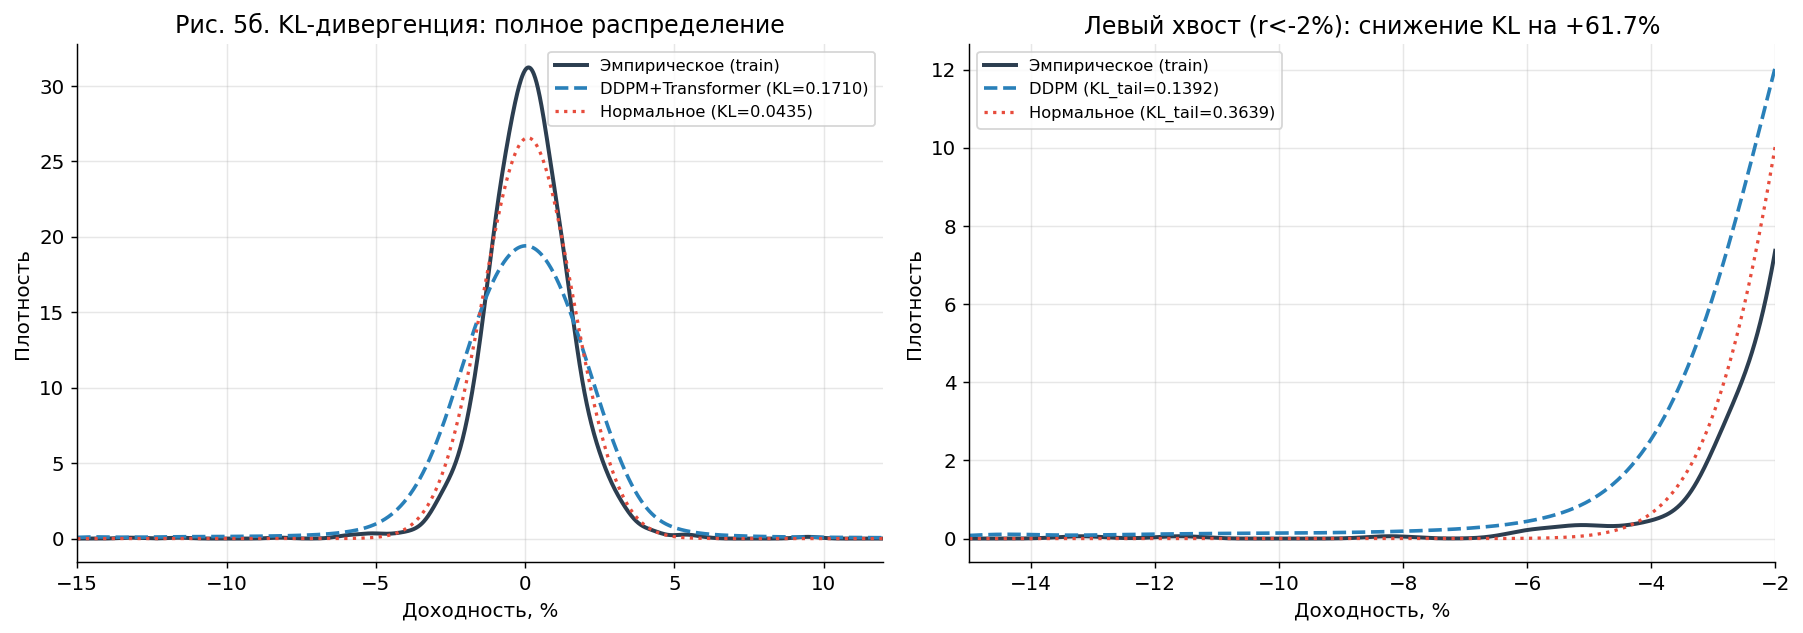

Рис. 5б перегенерирован с хвостовым KL


In [33]:
# KL-дивергенция: симметричная + хвостовая

ctx_last = train_arr[-W:]
N_KL = 50_000  # большая выборка для устойчивой оценки хвоста
scen_ddpm = generate_scenarios(ctx_last, trained_models['tr_huber15'], n=N_KL)

mu_tr, sd_tr = train_arr.mean(), train_arr.std(ddof=1)
GRID_LO, GRID_HI, NGRID = -0.15, 0.15, 2000  # сетка в долях (±15%)
grid = np.linspace(GRID_LO, GRID_HI, NGRID)
dx = grid[1] - grid[0]

# KDE по эмпирическим train-данным, по сценариям DDPM и аналитическая N(mu,std)
kde_emp  = sps.gaussian_kde(train_arr, bw_method=0.25)
kde_ddpm = sps.gaussian_kde(scen_ddpm, bw_method=0.25)
p_emp    = kde_emp(grid);    p_emp  /= p_emp.sum()  * dx
p_ddpm   = kde_ddpm(grid);   p_ddpm /= p_ddpm.sum() * dx
p_norm   = sps.norm.pdf(grid, loc=mu_tr, scale=sd_tr)
p_norm  /= p_norm.sum() * dx

EPS = 1e-12
def kl_div(p, q):
    """KL(p || q), p и q — нормированные плотности на сетке."""
    p = np.clip(p, EPS, None); q = np.clip(q, EPS, None)
    return float(np.sum(p * np.log(p / q)) * dx)

def kl_sym(p, q):
    return 0.5 * (kl_div(p, q) + kl_div(q, p))

kl_sym_ddpm   = kl_sym(p_emp, p_ddpm)
kl_sym_normal = kl_sym(p_emp, p_norm)

TAIL_THRESH = -0.02  # -2%
tail_mask = grid < TAIL_THRESH

def kl_tail(p_emp_full, p_mod_full, mask):
    """KL на области, перенормировав плотности на этой области."""
    pe = p_emp_full[mask].copy()
    pm = p_mod_full[mask].copy()
    # перенормировка на области
    pe /= pe.sum() * dx
    pm /= pm.sum() * dx
    pe = np.clip(pe, EPS, None); pm = np.clip(pm, EPS, None)
    # симметричный KL на хвосте
    return 0.5 * (np.sum(pe * np.log(pe / pm)) * dx
                  + np.sum(pm * np.log(pm / pe)) * dx)

kl_tail_ddpm   = kl_tail(p_emp, p_ddpm, tail_mask)
kl_tail_normal = kl_tail(p_emp, p_norm, tail_mask)
tail_improvement = (1 - kl_tail_ddpm / kl_tail_normal) * 100

df_kl = pd.DataFrame({
    'Модель': ['DDPM+Transformer(Huber 1.5)', 'Нормальное'],
    'KL (симм.)':        [round(kl_sym_ddpm,   4), round(kl_sym_normal,   4)],
    'KL хвост (r<-2%)':  [round(kl_tail_ddpm,  4), round(kl_tail_normal,  4)],
})
print(df_kl.to_string(index=False))
print(f"\nСнижение хвостовой KL: {tail_improvement:+.1f}% "
      f"(DDPM относительно нормальной)")

df_kl.to_csv('table_kl_divergence.csv', index=False, encoding='utf-8-sig')

# --- 7. Новый рис. 5б с двумя панелями: общий и хвост ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (а) все распределения
ax = axes[0]
ax.plot(grid*100, p_emp,  color='#2C3E50', lw=2.2, label='Эмпирическое (train)')
ax.plot(grid*100, p_ddpm, color='#2980B9', lw=2.0, ls='--',
        label=f'DDPM+Transformer (KL={kl_sym_ddpm:.4f})')
ax.plot(grid*100, p_norm, color='#E74C3C', lw=1.8, ls=':',
        label=f'Нормальное (KL={kl_sym_normal:.4f})')
ax.set_xlim(-15, 12); ax.set_xlabel('Доходность, %')
ax.set_ylabel('Плотность')
ax.set_title('Рис. 5б. KL-дивергенция: полное распределение')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (б) хвост r < -2%
ax = axes[1]
mask_plot = grid < TAIL_THRESH
ax.plot(grid[mask_plot]*100, p_emp[mask_plot],  color='#2C3E50', lw=2.2,
        label='Эмпирическое (train)')
ax.plot(grid[mask_plot]*100, p_ddpm[mask_plot], color='#2980B9', lw=2.0, ls='--',
        label=f'DDPM (KL_tail={kl_tail_ddpm:.4f})')
ax.plot(grid[mask_plot]*100, p_norm[mask_plot], color='#E74C3C', lw=1.8, ls=':',
        label=f'Нормальное (KL_tail={kl_tail_normal:.4f})')
ax.set_xlim(-15, -2); ax.set_xlabel('Доходность, %')
ax.set_ylabel('Плотность')
ax.set_title(f'Левый хвост (r<-2%): снижение KL на {tail_improvement:+.1f}%')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig05b_kl_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Рис. 5б перегенерирован с хвостовым KL')

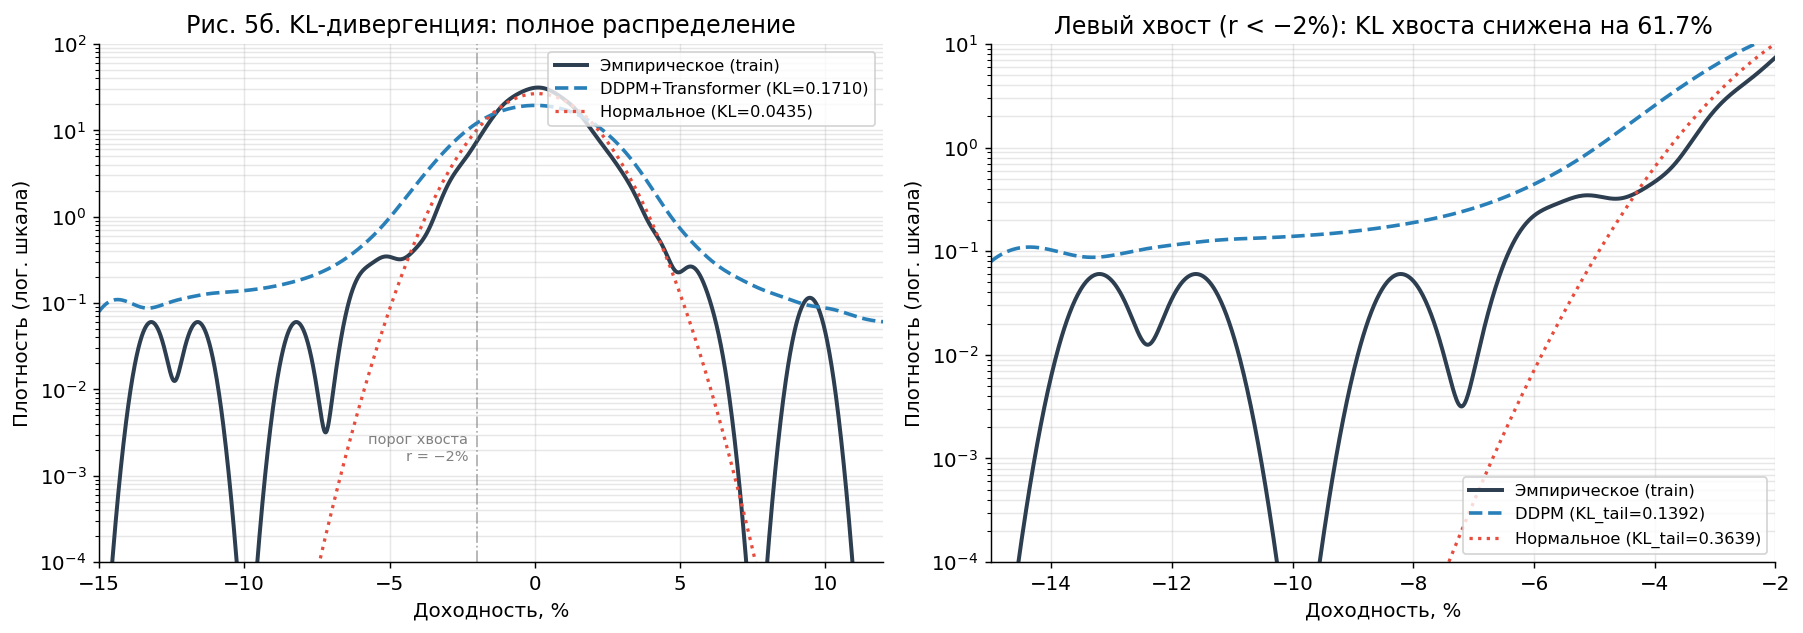

Рис. 5б (лог-шкала) сохранён


In [34]:
# ============================================================
# Рис. 5б — улучшенная версия с лог-шкалой
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (а) Полное распределение в логарифмической шкале по Y —
# видно одновременно и центр, и хвост
ax = axes[0]
ax.plot(grid*100, p_emp,  color='#2C3E50', lw=2.2, label='Эмпирическое (train)')
ax.plot(grid*100, p_ddpm, color='#2980B9', lw=2.0, ls='--',
        label=f'DDPM+Transformer (KL={kl_sym_ddpm:.4f})')
ax.plot(grid*100, p_norm, color='#E74C3C', lw=1.8, ls=':',
        label=f'Нормальное (KL={kl_sym_normal:.4f})')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e2)
ax.set_xlim(-15, 12)
ax.set_xlabel('Доходность, %')
ax.set_ylabel('Плотность (лог. шкала)')
ax.set_title('Рис. 5б. KL-дивергенция: полное распределение')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3, which='both')
ax.axvline(-2, color='gray', ls='-.', lw=1, alpha=0.6)
ax.text(-2.3, 1.5e-3, 'порог хвоста\nr = −2%', ha='right', fontsize=8,
        color='gray')

# (б) Левый хвост r < -2% — показываем ИСХОДНЫЕ плотности
# (не перенормированные): видно, что DDPM ближе к эмпирической кривой
ax = axes[1]
mask_plot = (grid >= -0.15) & (grid < TAIL_THRESH)
ax.plot(grid[mask_plot]*100, p_emp[mask_plot],  color='#2C3E50', lw=2.2,
        label='Эмпирическое (train)')
ax.plot(grid[mask_plot]*100, p_ddpm[mask_plot], color='#2980B9', lw=2.0, ls='--',
        label=f'DDPM (KL_tail={kl_tail_ddpm:.4f})')
ax.plot(grid[mask_plot]*100, p_norm[mask_plot], color='#E74C3C', lw=1.8, ls=':',
        label=f'Нормальное (KL_tail={kl_tail_normal:.4f})')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e1)
ax.set_xlim(-15, -2)
ax.set_xlabel('Доходность, %')
ax.set_ylabel('Плотность (лог. шкала)')
ax.set_title(f'Левый хвост (r < −2%): KL хвоста снижена на {tail_improvement:.1f}%')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('figures/fig05b_kl_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Рис. 5б (лог-шкала) сохранён')

In [26]:
# Метрические функции

def kupiec_test(actual: np.ndarray, var_fc: np.ndarray,
                alpha: float = ALPHA) -> Dict:
    """
    Тест Купика (POF): H_0: доля нарушений = 1 - alpha.
    LR = -2 * log(L_0 / L_1) ~ chi^2(1). p > 0.05 — VaR откалиброван.
    """
    hits  = (-actual > np.array(var_fc)).astype(float)
    n     = len(hits); x = hits.sum(); p = x / n; p0 = 1 - alpha
    viol_pct = round(p * 100, 2)
    if x == 0 or x == n:
        return {'p_value': float('nan'), 'verdict': 'н/д',
                'violation_pct': viol_pct, 'n_violations': int(x)}
    lr = -2 * ((x * np.log(p0) + (n - x) * np.log(1 - p0))
               - (x * np.log(p)  + (n - x) * np.log(1 - p)))
    pv = 1 - stats.chi2.cdf(lr, df=1)
    return {'p_value': round(pv, 4),
            'verdict': 'H0 не откл.' if pv > 0.05 else 'H0 откл.',
            'violation_pct': viol_pct, 'n_violations': int(x)}


def christoffersen_test(actual: np.ndarray, var_fc: np.ndarray,
                        alpha: float = ALPHA) -> Dict:
    """
    Тест Кристофферсена (CC): H_0: нарушения независимы и доля = 1 - alpha.
    LR_cc = LR_uc + LR_ind ~ chi^2(2). Обнаруживает кластеризацию нарушений.
    """
    hits = (-actual > np.array(var_fc)).astype(int); n = len(hits)
    n00  = int(np.sum((hits[:-1]==0) & (hits[1:]==0)))
    n01  = int(np.sum((hits[:-1]==0) & (hits[1:]==1)))
    n10  = int(np.sum((hits[:-1]==1) & (hits[1:]==0)))
    n11  = int(np.sum((hits[:-1]==1) & (hits[1:]==1)))
    pi01 = n01/(n00+n01) if (n00+n01)>0 else 1e-10
    pi11 = n11/(n10+n11) if (n10+n11)>0 else 1e-10
    pi   = (n01+n11)/max(n, 1)
    sl   = lambda x: np.log(max(x, 1e-10))
    lr_ind = max(-2*((n00+n10)*sl(1-pi)+(n01+n11)*sl(pi)
                     -n00*sl(1-pi01)-n01*sl(pi01)
                     -n10*sl(1-pi11)-n11*sl(pi11)), 0)
    p_ind  = 1 - stats.chi2.cdf(lr_ind, df=1)
    x = hits.sum(); ph = x/n; p0 = 1 - alpha
    lr_uc = max(-2*((x*sl(p0)+(n-x)*sl(1-p0))-(x*sl(ph)+(n-x)*sl(1-ph))), 0)
    p_cc  = 1 - stats.chi2.cdf(lr_uc+lr_ind, df=2)
    return {'p_cc':  round(p_cc, 4),
            'ind_v': 'Независимы' if p_ind > 0.05 else 'Кластеризованы',
            'cc_v':  'H0 не откл.' if p_cc > 0.05 else 'H0 откл.'}


def tick_loss(actual: np.ndarray, var_fc: np.ndarray, alpha: float = ALPHA) -> float:
    """
    Quantile loss (pinball loss): rho_alpha(r, q) = (alpha - 1{r<q}) * (r - q).
    """
    q = -np.array(var_fc)
    return float(((alpha - (actual < q).astype(float)) * (actual - q)).mean())


def mcneil_frey_test(actual: np.ndarray, var_fc: np.ndarray,
                     es_fc: np.ndarray) -> Dict:
    """
    Тест McNeil & Frey (2000) для Expected Shortfall.
    H_0: E[r_t + ES_t | r_t < -VaR_t] = 0. p > 0.05 — ES откалиброван.
    """
    mask = (-actual > np.array(var_fc)); nh = mask.sum()
    if nh < 3:
        return {'n_hits': int(nh), 'p_value': float('nan'),
                'verdict': 'недостаточно нарушений'}
    res = actual[mask] + (-np.array(es_fc)[mask])
    _, pv = stats.ttest_1samp(res, 0)
    return {'n_hits':        int(nh),
            'mean_residual': round(float(res.mean() * 100), 3),
            'p_value':       round(float(pv), 4),
            'verdict':       'ES корректен' if pv > 0.05 else 'ES смещён'}


def bootstrap_ci(actual: np.ndarray, var_fc: np.ndarray,
                 n_boot: int = 1000, seed: int = SEED,
                 alpha: float = ALPHA) -> Dict:
    """Bootstrap 95% CI для доли нарушений и tick loss (1000 итераций)."""
    rng = np.random.default_rng(seed); n = len(actual); va = np.array(var_fc)
    viol_b, tick_b = [], []
    for _ in range(n_boot):
        idx  = rng.integers(0, n, size=n); ab, vb = actual[idx], va[idx]
        viol_b.append((-ab > vb).mean() * 100)
        q = -vb
        tick_b.append(((alpha - (ab < q).astype(float)) * (ab - q)).mean())
    return {
        'viol_ci': (round(np.percentile(viol_b, 2.5), 2),
                    round(np.percentile(viol_b, 97.5), 2)),
        'tick_ci': (round(np.percentile(tick_b, 2.5), 5),
                    round(np.percentile(tick_b, 97.5), 5)),
    }


def diebold_mariano_test(actual: np.ndarray, var_a: np.ndarray,
                         var_b: np.ndarray, alpha: float = ALPHA) -> Dict:
    """
    Тест Дибольда-Мариано (1995): H_0: равная точность прогнозов по tick loss.
    d_t = L_A(t) - L_B(t), DM-статистика ~ N(0,1) под H_0.
    """
    qa = -np.array(var_a); qb = -np.array(var_b)
    la = (alpha - (actual < qa).astype(float)) * (actual - qa)
    lb = (alpha - (actual < qb).astype(float)) * (actual - qb)
    d  = la - lb; n = len(d)
    se = np.sqrt(max(np.var(d, ddof=1) / n, 1e-12))
    dm = d.mean() / se
    pv = 2 * (1 - stats.norm.cdf(abs(dm)))
    return {'DM_stat': round(float(dm), 4), 'p_value': round(float(pv), 4),
            'verdict': 'Значимо' if pv < 0.05 else 'Незначимо',
            'better':  'A' if d.mean() < 0 else 'B'}


def crps_empirical(r: float, scen: np.ndarray) -> float:
    """CRPS через NRG-форму: CRPS(F, y) = E|X-y| - 0.5*E|X-X'|. O(M log M)."""
    M = len(scen); ss = np.sort(scen); idx = np.arange(1, M + 1)
    t1 = np.mean(np.abs(scen - r))
    t2 = (2 / M**2) * np.sum(ss * (2 * idx - M - 1))
    return float(t1 - 0.5 * t2)


def crps_normal(y: float, mu: float, sigma: float) -> float:
    """Аналитический CRPS для Normal(mu, sigma^2) (Gneiting & Raftery, 2007)."""
    z = (y - mu) / sigma
    return float(sigma * (z * (2 * stats.norm.cdf(z) - 1)
                          + 2 * stats.norm.pdf(z)
                          - 1 / math.sqrt(math.pi)))


def crps_t_simulated(y: float, sigma: float, nu: float, n_sim: int = 2000) -> float:
    """CRPS для Student-t(0, sigma, nu) через симуляцию."""
    rng     = np.random.default_rng(SEED)
    samples = sigma * stats.t.rvs(df=nu, size=n_sim,
                                   random_state=int(rng.integers(1_000_000)))
    return crps_empirical(y, samples)


def pit_normal(r, mu, sigma):
    return float(stats.norm.cdf(r, loc=mu, scale=sigma))

def pit_student_t(r, sigma, nu):
    return float(stats.t.cdf(r / sigma, df=nu))

def pit_empirical_fn(r, scen):
    return float(np.sum(scen <= r) / len(scen))

def pit_historical_fn(r, window):
    return float(np.sum(window <= r) / len(window))

def basel_traffic_light(n_viol: int, n_days: int) -> str:
    """Классификация Basel III, масштабированная к 250-дневному горизонту."""
    v250 = round(n_viol * 250 / n_days)
    if   v250 <= 4: return f'Зеленая ({v250}/250)'
    elif v250 <= 9: return f'Желтая ({v250}/250)'
    else:           return f'Красная ({v250}/250)'


print('Метрические функции определены.')

Метрические функции определены.


In [27]:
# Полный бэктест (744 наблюдения, STEP=1)

NAMES = {
    'normal':   'Нормальное',
    'hist':     'Историческое',
    'garch':    'GARCH(1,1)-t',
    'ddpm_tr':  'DDPM+Transformer(Huber_1.5)',
    'ddpm_mlp': 'DDPM+MLP',
}


def _save_backtest(results: Dict, day_idx: int) -> None:
    safe = {k: {f: [float(x) if f != 'idx' else int(x) for x in v[f]]
                for f in v} for k, v in results.items()}
    with open(CKPT['backtest'], 'w') as f:
        json.dump({'results': safe, 'last_day': day_idx}, f)


def _load_backtest() -> Tuple[Optional[Dict], int]:
    if not os.path.exists(CKPT['backtest']):
        return None, 0
    with open(CKPT['backtest']) as f:
        ck = json.load(f)
    n_saved = len(ck['results'].get('normal', {}).get('idx', []))
    print(f'Загружен чекпоинт: день {ck["last_day"]}, записей {n_saved}')
    return ck['results'], ck['last_day'] + 1


saved_bt, start_day = _load_backtest()
if saved_bt is not None:
    results = saved_bt
else:
    results = {m: {'var': [], 'es': [], 'idx': [], 'pit': [], 'crps': []}
               for m in NAMES}
    start_day = 0

# Восстановление цепи GARCH sigma^2 до начала тестового периода
_s2 = float(np.var(train_arr))
_omega, _a, _b, _ = garch_model.params_
for _r in train_arr:
    _s2 = _omega + _a * _r**2 + _b * _s2
garch_model._last_sigma2 = _s2
print(f'GARCH sigma восстановлена: {math.sqrt(_s2)*100:.3f}%')

print(f'\nБэктест VaR(99%), 2022-2024')
print(f'Все 5 моделей, STEP={BACKTEST_STEP}, N_scenarios={N_SCENARIOS}')
print(f'Начало с дня {start_day} / {n_test}')

t_bt = time.time()
for i in range(start_day, n_test):
    idx   = n_train + i
    r_act = float(all_arr[idx])

    # GARCH: обновление sigma^2 каждый день (требование марковской цепи)
    v_g, c_g, sig_g = garch_model.forecast_step(all_arr[idx - 1])
    nu_g = float(garch_model.params_[3])

    w_base = all_arr[max(0, idx - WINDOW_BT): idx]
    mu_w   = float(w_base.mean())
    sig_w  = float(w_base.std(ddof=1))

    v_n, c_n = var_cvar_normal(w_base)
    results['normal']['var'].append(v_n);  results['normal']['es'].append(c_n)
    results['normal']['idx'].append(i)
    results['normal']['pit'].append(pit_normal(r_act, mu_w, sig_w))
    results['normal']['crps'].append(crps_normal(r_act, mu_w, sig_w))

    v_h, c_h = var_cvar_historical(w_base)
    results['hist']['var'].append(v_h);    results['hist']['es'].append(c_h)
    results['hist']['idx'].append(i)
    results['hist']['pit'].append(pit_historical_fn(r_act, w_base))
    results['hist']['crps'].append(crps_empirical(r_act, w_base))

    results['garch']['var'].append(v_g);   results['garch']['es'].append(c_g)
    results['garch']['idx'].append(i)
    results['garch']['pit'].append(pit_student_t(r_act, sig_g, nu_g))
    results['garch']['crps'].append(crps_t_simulated(r_act, sig_g, nu_g))

    ctx_w = all_arr[max(0, idx - W): idx]
    if len(ctx_w) < W:
        ctx_w = np.pad(ctx_w, (W - len(ctx_w), 0), mode='edge')

    sc_tr   = generate_scenarios(ctx_w, trained_models['tr_huber15'], n=N_SCENARIOS)
    los_tr  = -sc_tr
    v_tr    = float(np.quantile(los_tr, ALPHA))
    c_tr    = float(los_tr[los_tr >= v_tr].mean()) if (los_tr >= v_tr).any() else v_tr
    results['ddpm_tr']['var'].append(v_tr);  results['ddpm_tr']['es'].append(c_tr)
    results['ddpm_tr']['idx'].append(i)
    results['ddpm_tr']['pit'].append(pit_empirical_fn(r_act, sc_tr))
    results['ddpm_tr']['crps'].append(crps_empirical(r_act, sc_tr))
    del sc_tr

    sc_mlp  = generate_scenarios(ctx_w, trained_models['mlp_mse'], n=N_SCENARIOS)
    los_mlp = -sc_mlp
    v_mlp   = float(np.quantile(los_mlp, ALPHA))
    c_mlp   = float(los_mlp[los_mlp >= v_mlp].mean()) if (los_mlp >= v_mlp).any() else v_mlp
    results['ddpm_mlp']['var'].append(v_mlp); results['ddpm_mlp']['es'].append(c_mlp)
    results['ddpm_mlp']['idx'].append(i)
    results['ddpm_mlp']['pit'].append(pit_empirical_fn(r_act, sc_mlp))
    results['ddpm_mlp']['crps'].append(crps_empirical(r_act, sc_mlp))
    del sc_mlp

    if torch.cuda.is_available() and i % 50 == 0:
        torch.cuda.empty_cache(); gc.collect()

    if (i + 1) % 100 == 0:
        _save_backtest(results, i)
        elapsed = time.time() - t_bt
        done    = i - start_day + 1
        rem     = elapsed / done * (n_test - i - 1)
        print(f'  [{i+1}/{n_test}] {(i+1)/n_test*100:.1f}% | '
              f'{elapsed/60:.1f} мин (+{rem/60:.1f} мин) | sigma_GARCH={sig_g*100:.2f}%')

_save_backtest(results, n_test - 1)
print(f'\nБэктест завершён за {(time.time()-t_bt)/60:.1f} мин')
sizes = {k: len(v['idx']) for k, v in results.items()}
assert len(set(sizes.values())) == 1
print(f'Записей на модель: {list(sizes.values())[0]}')

GARCH sigma восстановлена: 1.260%

Бэктест VaR(99%), 2022-2024
Все 5 моделей, STEP=1, N_scenarios=1000
Начало с дня 0 / 744
  [100/744] 13.4% | 1.1 мин (+7.3 мин) | sigma_GARCH=1.47%
  [200/744] 26.9% | 2.3 мин (+6.1 мин) | sigma_GARCH=1.44%
  [300/744] 40.3% | 3.4 мин (+5.0 мин) | sigma_GARCH=1.17%
  [400/744] 53.8% | 4.5 мин (+3.9 мин) | sigma_GARCH=1.15%
  [500/744] 67.2% | 5.6 мин (+2.7 мин) | sigma_GARCH=0.76%
  [600/744] 80.6% | 6.8 мин (+1.6 мин) | sigma_GARCH=1.10%
  [700/744] 94.1% | 7.9 мин (+0.5 мин) | sigma_GARCH=1.11%

Бэктест завершён за 8.4 мин
Записей на модель: 744


In [28]:
# Расчёт метрик и итоговые таблицы (Таблицы 3 и 6)

print('Расчёт метрик (bootstrap CI)...')
metrics = {}
for key, name in NAMES.items():
    var_arr = np.array(results[key]['var'])
    es_arr  = np.array(results[key]['es'])
    idx_l   = results[key]['idx']
    act_arr = test_arr[idx_l]
    pit_arr = np.array(results[key]['pit'])
    crps_v  = float(np.array(results[key]['crps']).mean())

    kup  = kupiec_test(act_arr, var_arr)
    chr_ = christoffersen_test(act_arr, var_arr)
    tl   = tick_loss(act_arr, var_arr)
    mf   = mcneil_frey_test(act_arr, var_arr, es_arr)
    boot = bootstrap_ci(act_arr, var_arr)
    _, pit_p = stats.kstest(pit_arr, 'uniform')

    metrics[key] = {
        'name':    name,
        'n_obs':   len(act_arr),
        'var_mean': round(float(var_arr.mean() * 100), 3),
        'es_mean':  round(float(es_arr.mean() * 100), 3),
        'viol_pct': kup['violation_pct'],
        'n_viol':   kup['n_violations'],
        'viol_ci':  boot['viol_ci'],
        'kup_p':    kup['p_value'],
        'kup_v':    kup['verdict'],
        'ind_v':    chr_['ind_v'],
        'cc_v':     chr_['cc_v'],
        'basel':    basel_traffic_light(kup['n_violations'], len(act_arr)),
        'tick':     round(tl, 5),
        'tick_ci':  boot['tick_ci'],
        'crps':     round(crps_v, 5),
        'pit_p':    round(pit_p, 4),
        'mf_v':     mf['verdict'],
        'mf_p':     mf['p_value'],
    }
    print(f'  {name:30s}: {kup["violation_pct"]:5.2f}% | {kup["verdict"]:12s} | '
          f'{basel_traffic_light(kup["n_violations"], len(act_arr))} | '
          f'tick={tl:.5f} | CRPS={crps_v:.5f}')

# Таблица 3
rows3 = []
for key, m in metrics.items():
    rows3.append({
        'Метод':       m['name'],
        'N':           m['n_obs'],
        'VaR,%':       m['var_mean'],
        'ES,%':        m['es_mean'],
        'Нар.,%':      m['viol_pct'],
        'N нар.':      m['n_viol'],
        'Viol 95%CI':  f"[{m['viol_ci'][0]},{m['viol_ci'][1]}]",
        'Купик p':     m['kup_p'],
        'Купик':       m['kup_v'],
        'Инд.':        m['ind_v'],
        'CC':          m['cc_v'],
        'Basel III':   m['basel'],
        'Quantile loss':   m['tick'],
        'Tick 95%CI':  f"[{m['tick_ci'][0]},{m['tick_ci'][1]}]",
        'CRPS':        m['crps'],
        'PIT KS p':    m['pit_p'],
        'ES тест':     m['mf_v'],
    })
t3_df = pd.DataFrame(rows3)
print(f'\nТаблица 3. Бэктест VaR(99%), 2022-2024 (N={metrics["normal"]["n_obs"]})')
print(t3_df.to_string(index=False))
t3_df.to_csv('results/table3_backtest.csv', index=False, encoding='utf-8-sig')

# Таблица 6: тест Дибольда-Мариано
print('\nТаблица 6. Тест Дибольда-Мариано (tick loss)')
dm_rows = []
for ka in NAMES:
    row = {'Модель A': NAMES[ka]}
    va  = np.array(results[ka]['var'])
    act = test_arr[results[ka]['idx']]
    for kb in NAMES:
        if ka == kb:
            row[NAMES[kb]] = '-'; continue
        vb  = np.array(results[kb]['var'])
        dm  = diebold_mariano_test(act, va, vb)
        row[NAMES[kb]] = f"p={dm['p_value']} {dm['verdict']} ({dm['better']})"
    dm_rows.append(row)
dm_df = pd.DataFrame(dm_rows)
print(dm_df.to_string(index=False))
dm_df.to_csv('results/table6_dm_test.csv', index=False, encoding='utf-8-sig')

Расчёт метрик (bootstrap CI)...
  Нормальное                    :  3.23% | H0 откл.     | Желтая (8/250) | tick=0.04800 | CRPS=0.01040
  Историческое                  :  1.75% | H0 не откл.  | Зеленая (4/250) | tick=0.05552 | CRPS=0.00988
  GARCH(1,1)-t                  :  1.21% | H0 не откл.  | Зеленая (3/250) | tick=0.04475 | CRPS=0.00949
  DDPM+Transformer(Huber_1.5)   :  0.67% | H0 не откл.  | Зеленая (2/250) | tick=0.05080 | CRPS=0.00966
  DDPM+MLP                      :  2.69% | H0 откл.     | Желтая (7/250) | tick=0.04054 | CRPS=0.00987

Таблица 3. Бэктест VaR(99%), 2022-2024 (N=744)
                      Метод   N  VaR,%   ES,%  Нар.,%  N нар.  Viol 95%CI  Купик p       Купик           Инд.          CC       Basel III  Quantile loss        Tick 95%CI    CRPS  PIT KS p   ES тест
                 Нормальное 744  4.749  5.444    3.23      24 [2.15,4.57]   0.0000    H0 откл.     Независимы    H0 откл.  Желтая (8/250)        0.04800  [0.04567,0.0503] 0.01040    0.0000 ES смещён
    

In [29]:
# Ablation A: сравнение архитектур денойзера (Таблица 4а)

print('\nТаблица 4(а). Ablation A: архитектура денойзера')
print('Обе модели оценены на 744 точках')

abl_a_data = {
    'Конфигурация':  ['DDPM+Transformer(Huber(1.5))', 'DDPM+MLP'],
    'Контекст W=30': ['Да (attention)',                'Нет'],
    'Параметров':    [f'{n_params_tr:,}',             f'{n_params_mlp:,}'],
    'VaR,%':         [metrics['ddpm_tr']['var_mean'],  metrics['ddpm_mlp']['var_mean']],
    'Нар.,%':        [metrics['ddpm_tr']['viol_pct'],  metrics['ddpm_mlp']['viol_pct']],
    'Viol CI':       [f"[{metrics['ddpm_tr']['viol_ci'][0]},{metrics['ddpm_tr']['viol_ci'][1]}]",
                      f"[{metrics['ddpm_mlp']['viol_ci'][0]},{metrics['ddpm_mlp']['viol_ci'][1]}]"],
    'Купик':         [metrics['ddpm_tr']['kup_v'],     metrics['ddpm_mlp']['kup_v']],
    'CC':            [metrics['ddpm_tr']['cc_v'],      metrics['ddpm_mlp']['cc_v']],
    'Basel III':     [metrics['ddpm_tr']['basel'],     metrics['ddpm_mlp']['basel']],
    'Tick loss':     [metrics['ddpm_tr']['tick'],      metrics['ddpm_mlp']['tick']],
    'Tick CI':       [f"[{metrics['ddpm_tr']['tick_ci'][0]},{metrics['ddpm_tr']['tick_ci'][1]}]",
                      f"[{metrics['ddpm_mlp']['tick_ci'][0]},{metrics['ddpm_mlp']['tick_ci'][1]}]"],
    'CRPS':          [metrics['ddpm_tr']['crps'],      metrics['ddpm_mlp']['crps']],
    'PIT KS p':      [metrics['ddpm_tr']['pit_p'],     metrics['ddpm_mlp']['pit_p']],
    'ES тест':       [metrics['ddpm_tr']['mf_v'],      metrics['ddpm_mlp']['mf_v']],
}
abl_a_df = pd.DataFrame(abl_a_data)
print(abl_a_df.to_string(index=False))
abl_a_df.to_csv('results/table4a_ablation_arch.csv', index=False, encoding='utf-8-sig')

dm_ab = diebold_mariano_test(
    test_arr[results['ddpm_tr']['idx']],
    np.array(results['ddpm_tr']['var']),
    np.array(results['ddpm_mlp']['var']))
t_tick = metrics['ddpm_tr']['tick']
m_tick = metrics['ddpm_mlp']['tick']
print(f'\nDM-тест Transformer vs MLP: DM={dm_ab["DM_stat"]}, p={dm_ab["p_value"]}, {dm_ab["verdict"]}')
print(f'Quantile loss: Transformer={t_tick:.5f}, MLP={m_tick:.5f}, '
      f'delta={( t_tick - m_tick)/m_tick*100:+.1f}%')
print(f'CRPS: Transformer={metrics["ddpm_tr"]["crps"]:.5f}, MLP={metrics["ddpm_mlp"]["crps"]:.5f}')


Таблица 4(а). Ablation A: архитектура денойзера
Обе модели оценены на 744 точках
                Конфигурация  Контекст W=30 Параметров  VaR,%  Нар.,%     Viol CI       Купик          CC       Basel III  Tick loss           Tick CI    CRPS  PIT KS p   ES тест
DDPM+Transformer(Huber(1.5)) Да (attention)    153,473  5.053    0.67 [0.13,1.34] H0 не откл. H0 не откл. Зеленая (2/250)    0.05080 [0.04896,0.05267] 0.00966     0.000 ES смещён
                    DDPM+MLP            Нет    212,225  3.978    2.69 [1.61,4.03]    H0 откл.    H0 откл.  Желтая (7/250)    0.04054 [0.03932,0.04181] 0.00987     0.024 ES смещён

DM-тест Transformer vs MLP: DM=13.6525, p=0.0, Значимо
Quantile loss: Transformer=0.05080, MLP=0.04054, delta=+25.3%
CRPS: Transformer=0.00966, MLP=0.00987


In [30]:
# Ablation B: функция потерь (Таблица 4б) + Режимный анализ (Таблица 5)

print('\nТаблица 4(б). Ablation B: функция потерь денойзера')

import json, os

def _read_meta(key):
    path = CKPT[key].replace('.pt', '_meta.json')
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        return round(m.get('val_mse', float('nan')), 5), m.get('epoch', '?')
    return float('nan'), '?'

vm_mse, ep_mse = _read_meta('tr_mse')
vm_h05, ep_h05 = _read_meta('tr_huber05')
vm_h15, ep_h15 = _read_meta('tr_huber15')
vm_h25, ep_h25 = _read_meta('tr_huber25')

def _delta(v):
    return round((v - vm_mse) / vm_mse * 100, 1)

def _note(key, v):
    configs = {'Huber(d=0.5)': vm_h05, 'Huber(d=1.5)': vm_h15, 'Huber(d=2.5)': vm_h25}
    is_best = v == min(vm_mse, vm_h05, vm_h15, vm_h25)
    notes = {
        'MSE':          'Baseline',
        'Huber(d=0.5)': 'Оптимальная: ~38% ошибок в линейной зоне' if is_best else '~38% ошибок в линейной зоне',
        'Huber(d=1.5)': '~13% ошибок в линейной зоне',
        'Huber(d=2.5)': 'Хуже MSE',
    }
    suffix = ' [наилучшая]' if is_best and key != 'MSE' else ''
    return notes[key] + suffix

loss_ablation_df = pd.DataFrame([
    {'Функция потерь': 'MSE',          'Val MSE': vm_mse, 'Best epoch': ep_mse,
     'Delta vs MSE,%': '-',            'Интерпретация': _note('MSE', vm_mse)},
    {'Функция потерь': 'Huber(d=0.5)', 'Val MSE': vm_h05, 'Best epoch': ep_h05,
     'Delta vs MSE,%': _delta(vm_h05), 'Интерпретация': _note('Huber(d=0.5)', vm_h05)},
    {'Функция потерь': 'Huber(d=1.5)', 'Val MSE': vm_h15, 'Best epoch': ep_h15,
     'Delta vs MSE,%': _delta(vm_h15), 'Интерпретация': _note('Huber(d=1.5)', vm_h15)},
    {'Функция потерь': 'Huber(d=2.5)', 'Val MSE': vm_h25, 'Best epoch': ep_h25,
     'Delta vs MSE,%': _delta(vm_h25), 'Интерпретация': _note('Huber(d=2.5)', vm_h25)},
])
print(loss_ablation_df.to_string(index=False))
loss_ablation_df.to_csv('results/table4b_ablation_loss.csv', index=False, encoding='utf-8-sig')

print('\nТаблица 5. Режимный анализ')
REGIMES = {
    'Кризис 2022':           (pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31')),
    'Восстановление 2023-24':(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-12-31')),
}
regime_rows = []
for regime_name, (r_start, r_end) in REGIMES.items():
    print(f'\n  {regime_name}:')
    for key, name in NAMES.items():
        idx_l   = np.array(results[key]['idx'])
        var_arr = np.array(results[key]['var'])
        act_arr = test_arr[idx_l]
        dates   = test_s.index[idx_l]
        mask    = (dates >= r_start) & (dates <= r_end)
        if mask.sum() == 0:
            continue
        v_sel, a_sel = var_arr[mask], act_arr[mask]
        crps_r = float(np.array(results[key]['crps'])[mask].mean())
        kup    = kupiec_test(a_sel, v_sel)
        tl     = tick_loss(a_sel, v_sel)
        print(f'    {name:30s}: {kup["violation_pct"]:5.2f}% | '
              f'{kup["verdict"]:12s} | tick={tl:.5f} | CRPS={crps_r:.5f}')
        regime_rows.append({'Период': regime_name, 'Метод': name,
                            'N': int(mask.sum()), 'Нар.,%': kup['violation_pct'],
                            'Купик': kup['verdict'], 'Tick': round(tl, 5),
                            'CRPS': round(crps_r, 5)})
pd.DataFrame(regime_rows).to_csv('results/table5_regime.csv', index=False, encoding='utf-8-sig')


Таблица 4(б). Ablation B: функция потерь денойзера
Функция потерь  Val MSE  Best epoch Delta vs MSE,%                           Интерпретация
           MSE  0.37235          39              -                                Baseline
  Huber(d=0.5)  0.37591          48            1.0             ~38% ошибок в линейной зоне
  Huber(d=1.5)  0.33253          43          -10.7 ~13% ошибок в линейной зоне [наилучшая]
  Huber(d=2.5)  0.51006          15           37.0                                Хуже MSE

Таблица 5. Режимный анализ

  Кризис 2022:
    Нормальное                    :  5.13% | H0 откл.     | tick=0.07579 | CRPS=0.01762
    Историческое                  :  3.85% | H0 откл.     | tick=0.08585 | CRPS=0.01691
    GARCH(1,1)-t                  :  3.42% | H0 откл.     | tick=0.06939 | CRPS=0.01603
    DDPM+Transformer(Huber_1.5)   :  2.14% | H0 не откл.  | tick=0.06935 | CRPS=0.01624
    DDPM+MLP                      :  8.55% | H0 откл.     | tick=0.04049 | CRPS=0.01690

  Восста

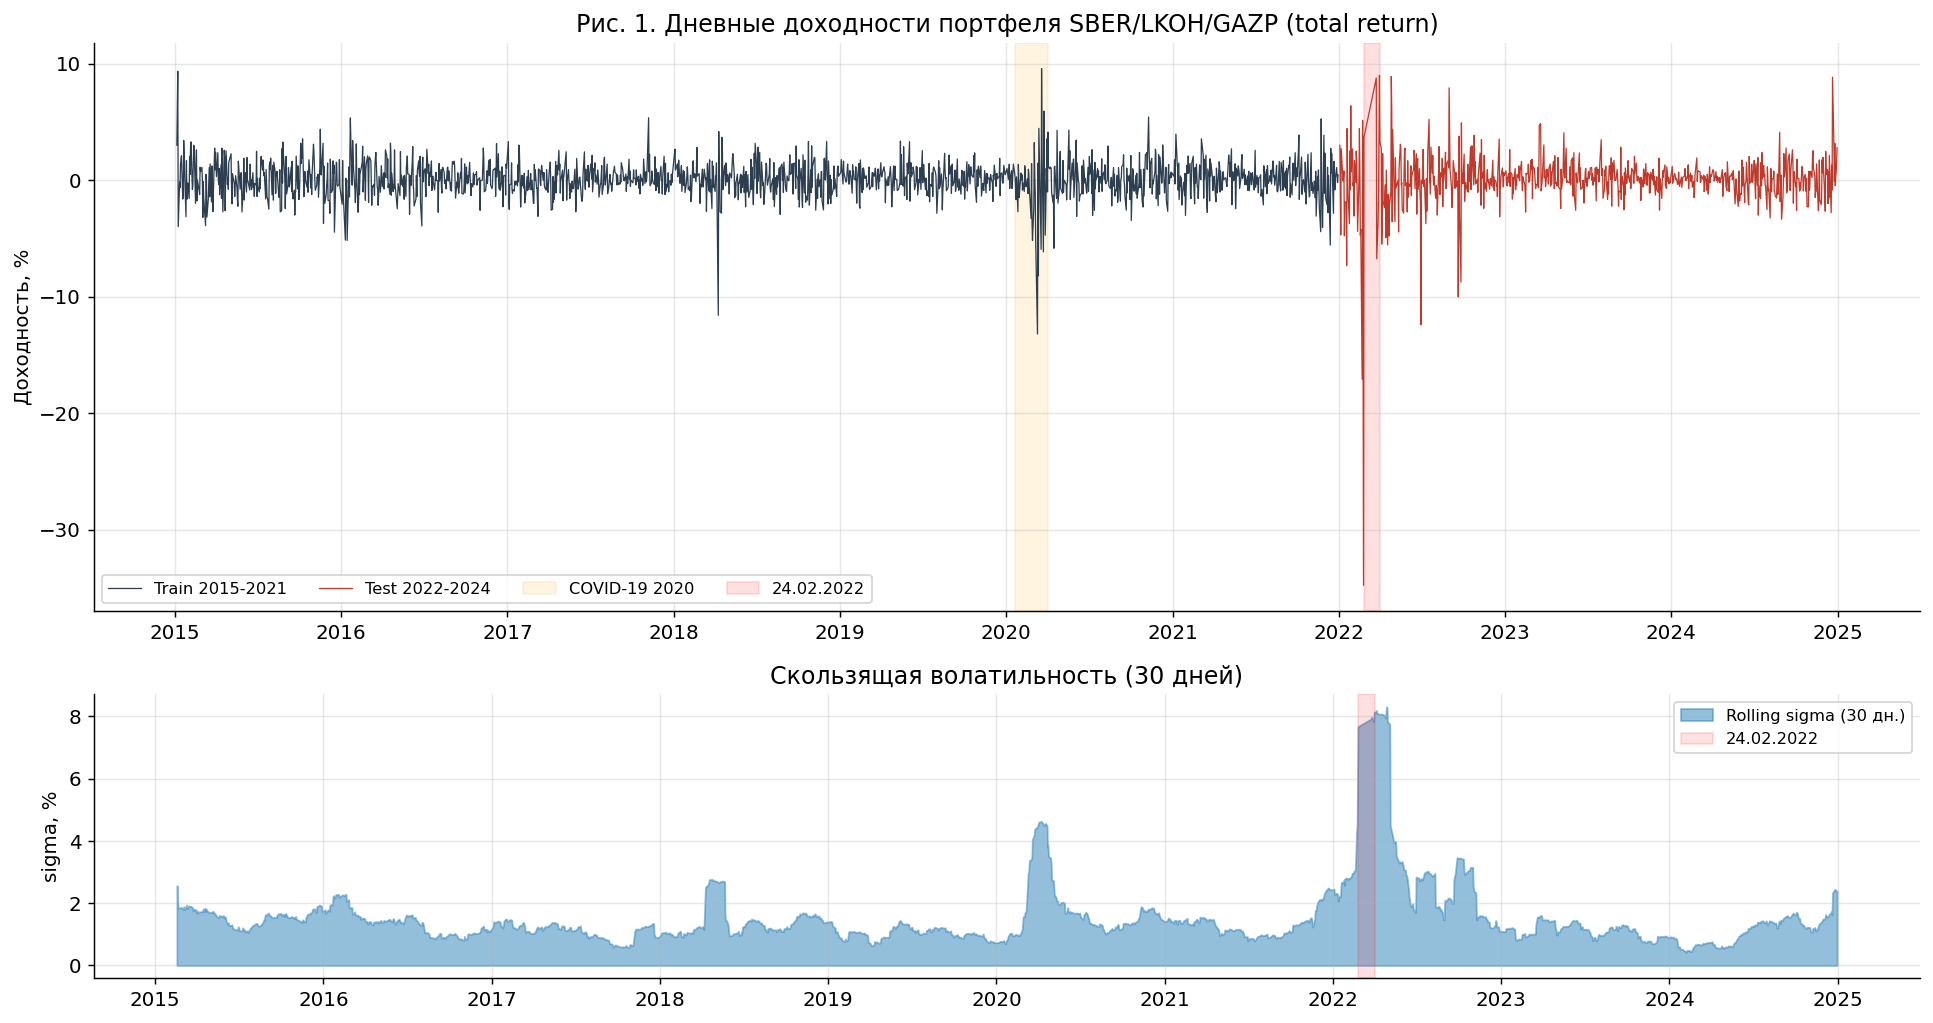

Рис. 1 сохранён


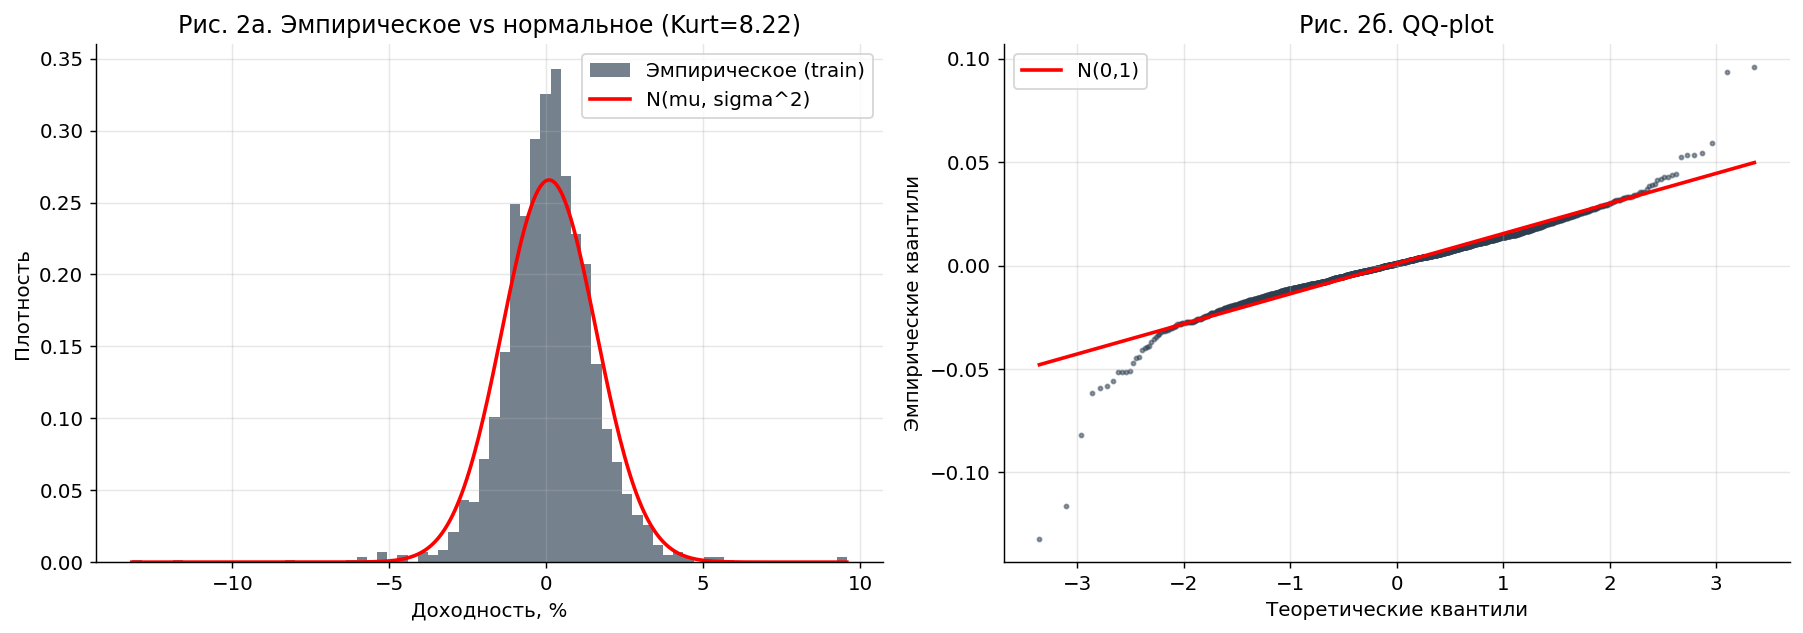

Рис. 2 сохранён


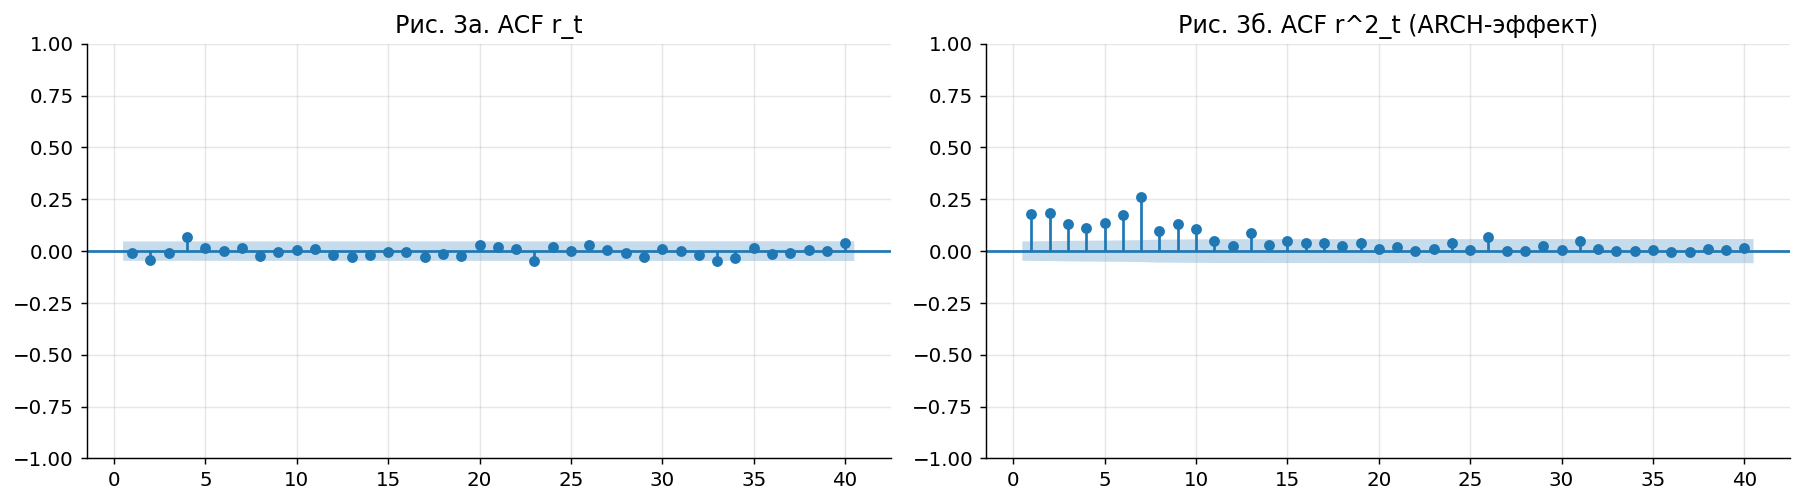

Рис. 3 сохранён


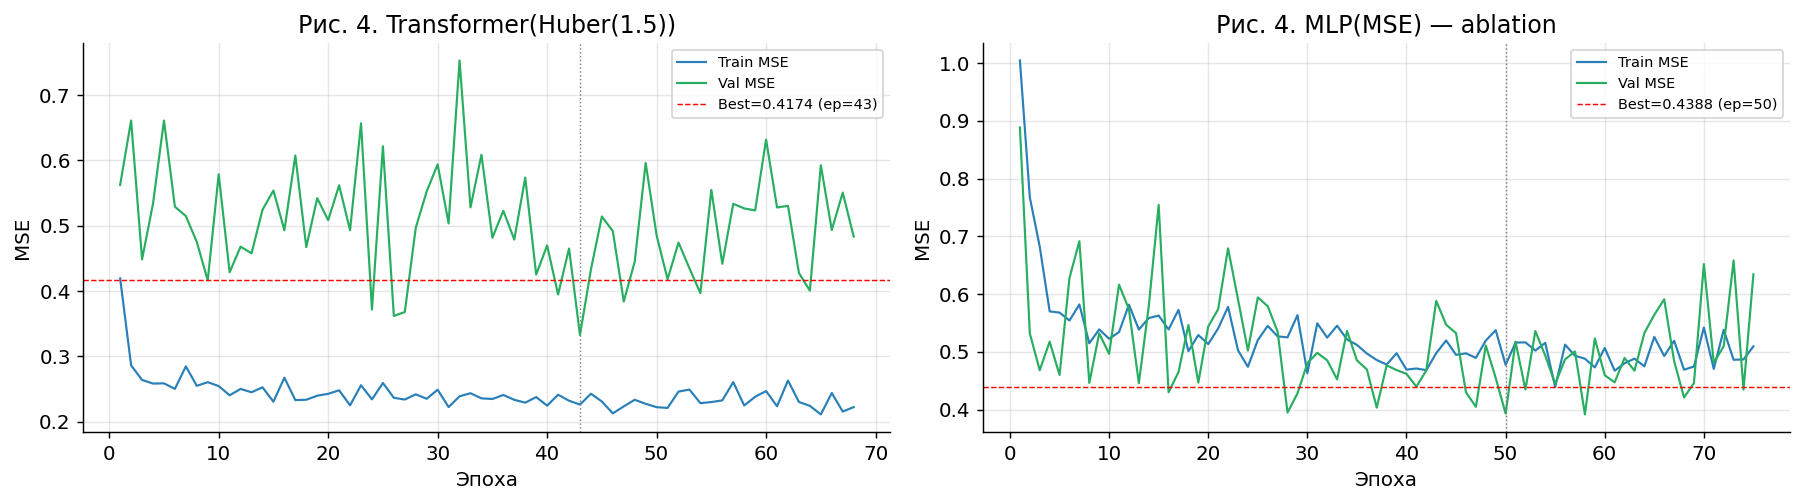

Рис. 4 сохранён


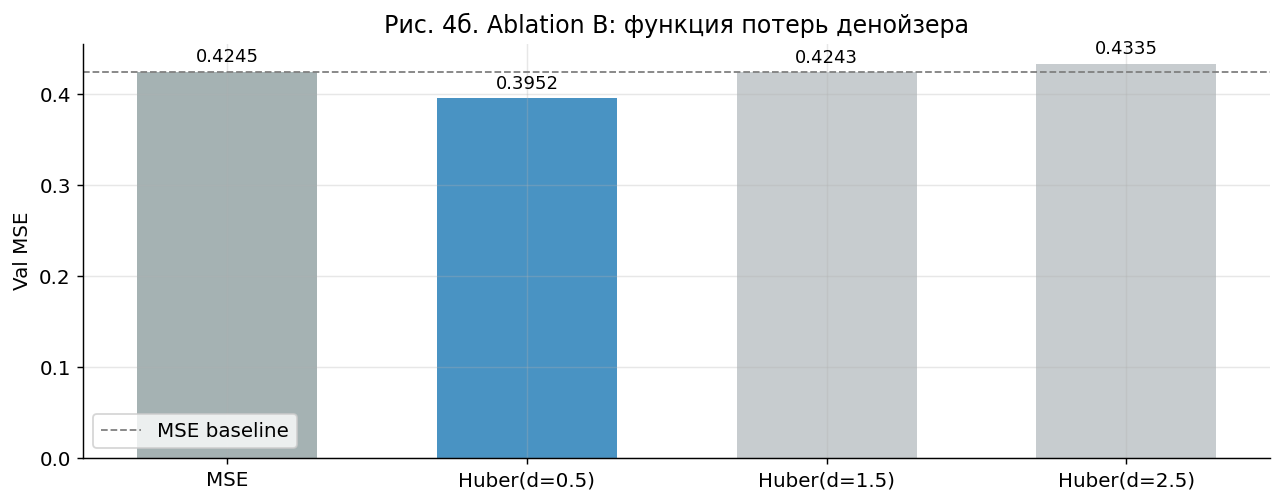

Рис. 4б сохранён


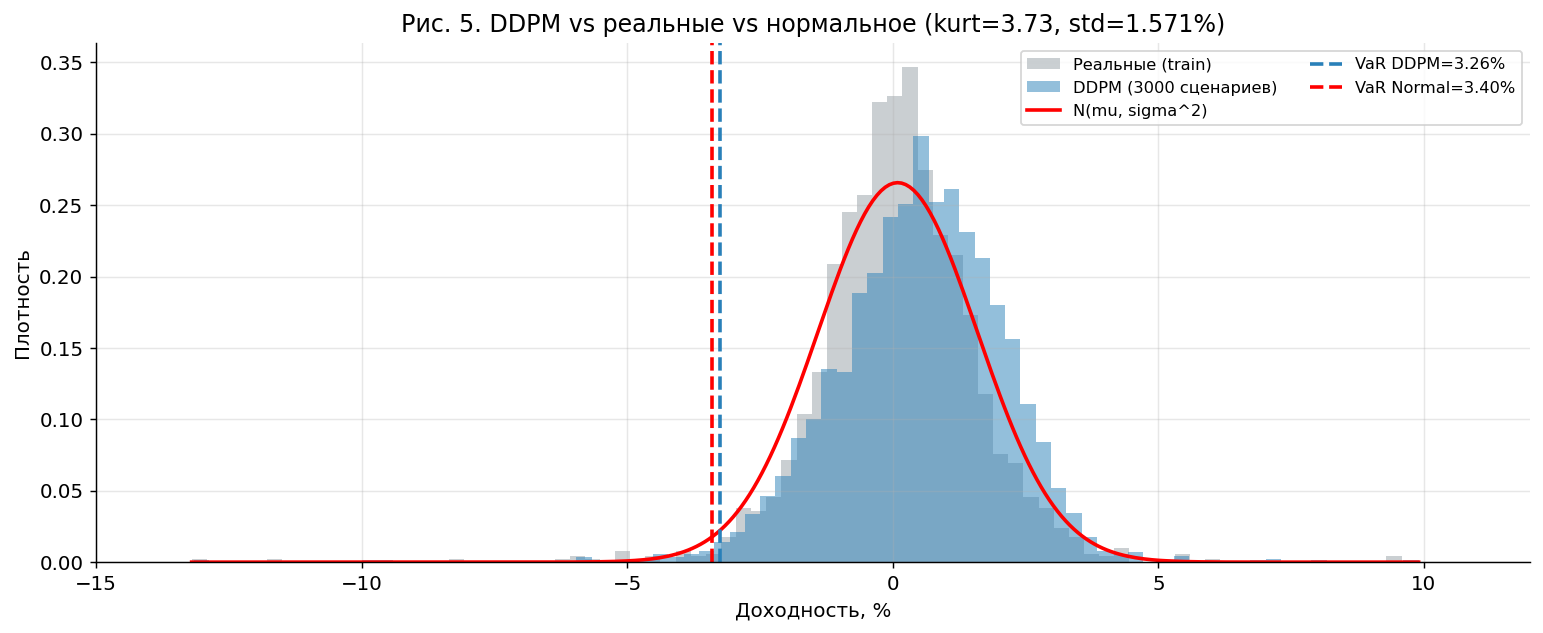

Рис. 5 сохранён
Генерация Fan Chart...


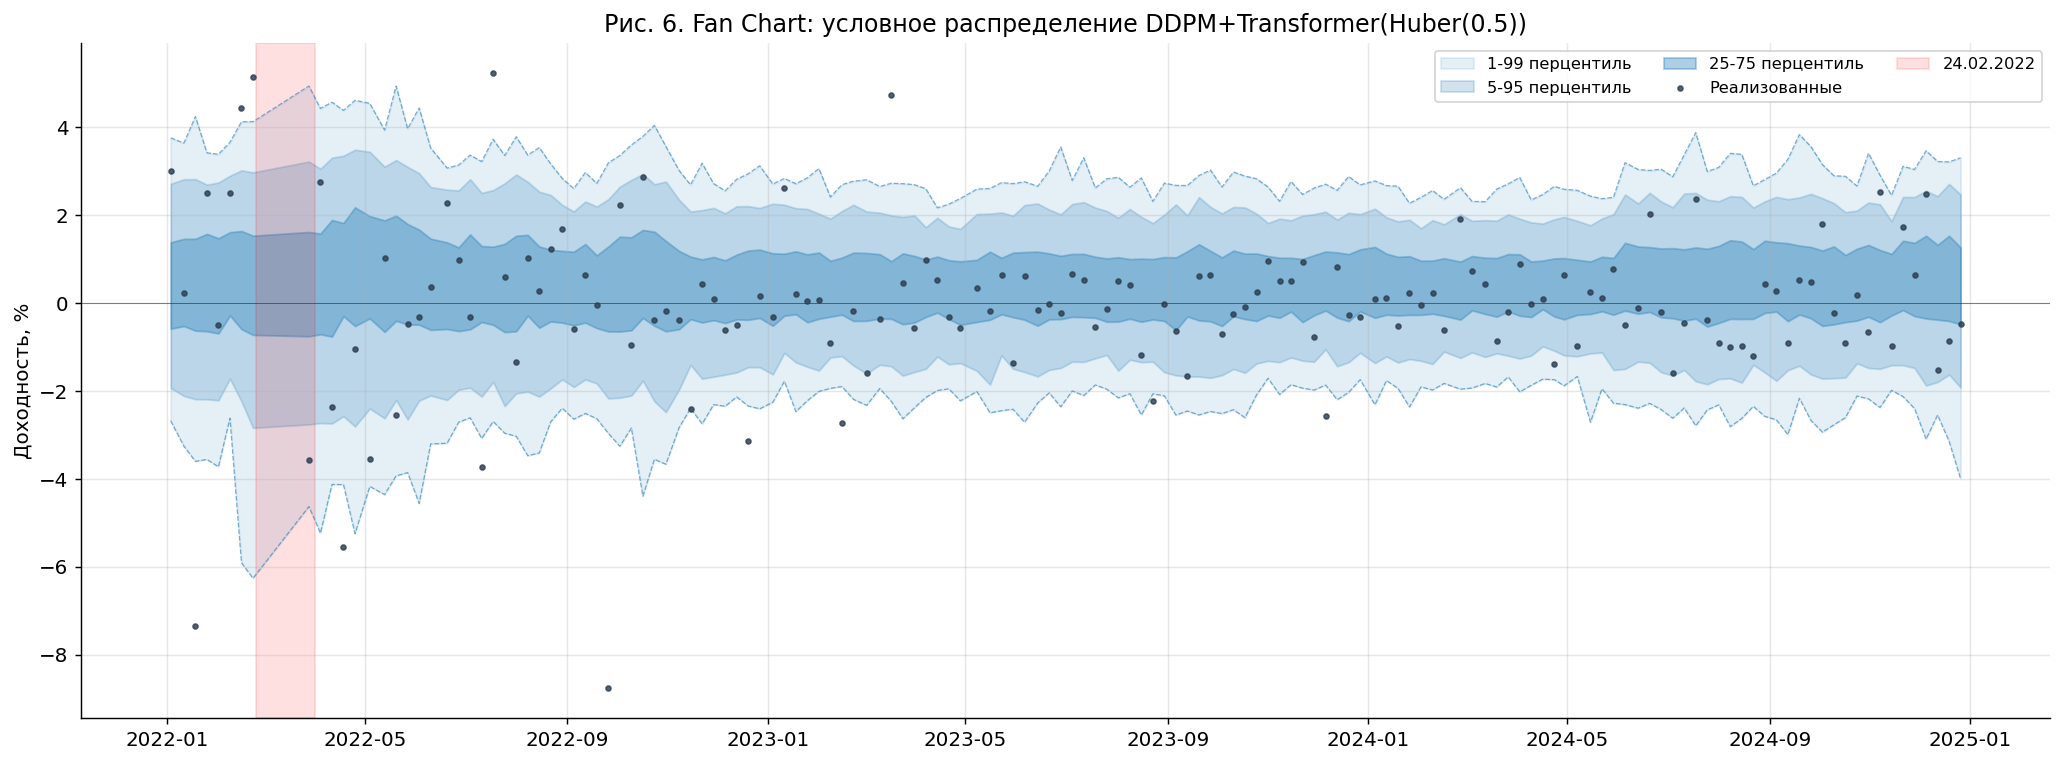

Рис. 6 сохранён


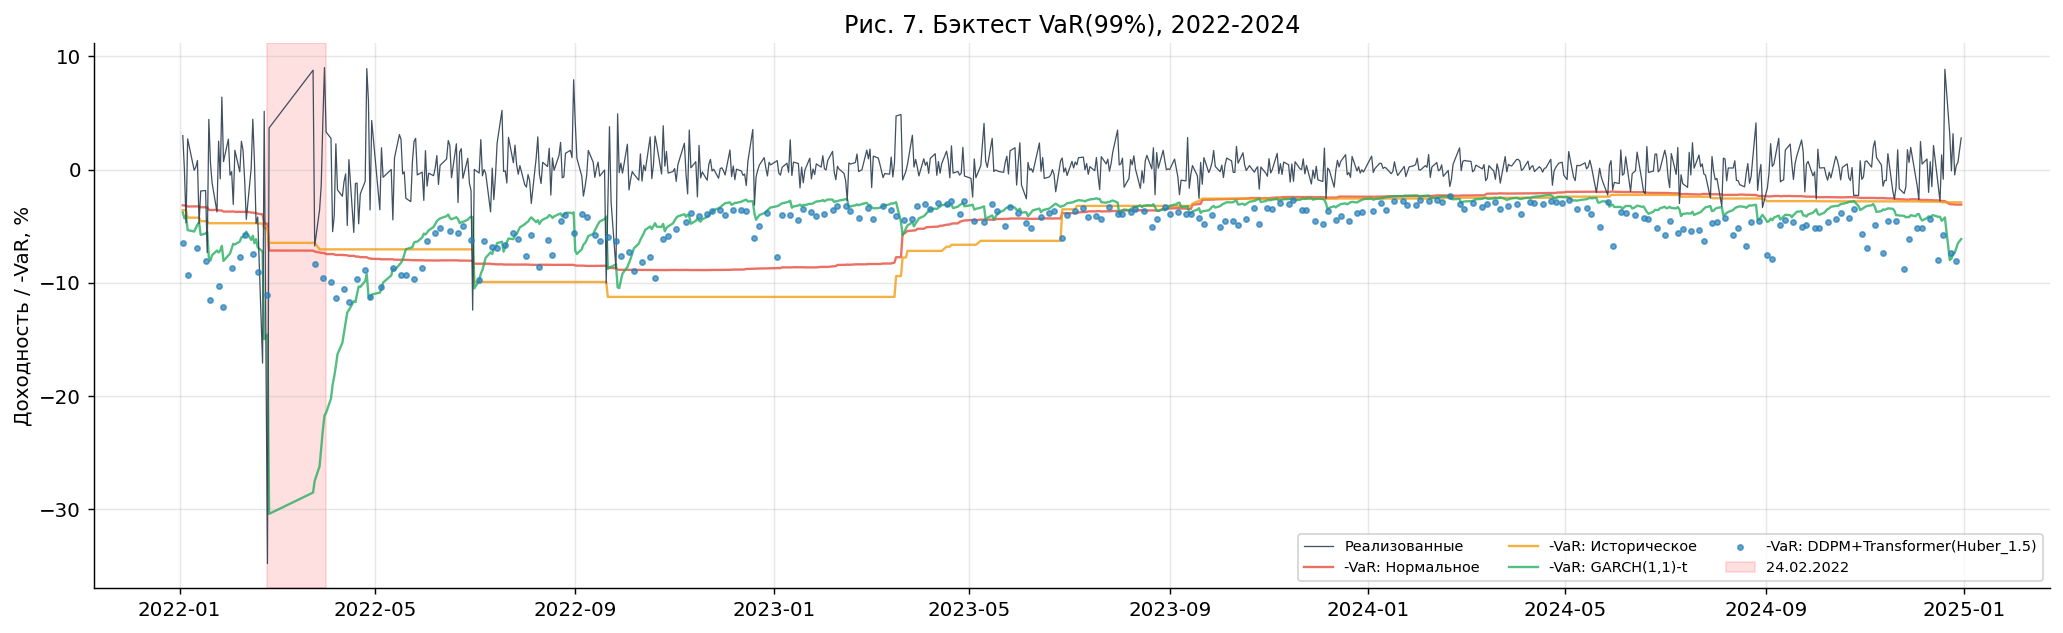

Рис. 7 сохранён


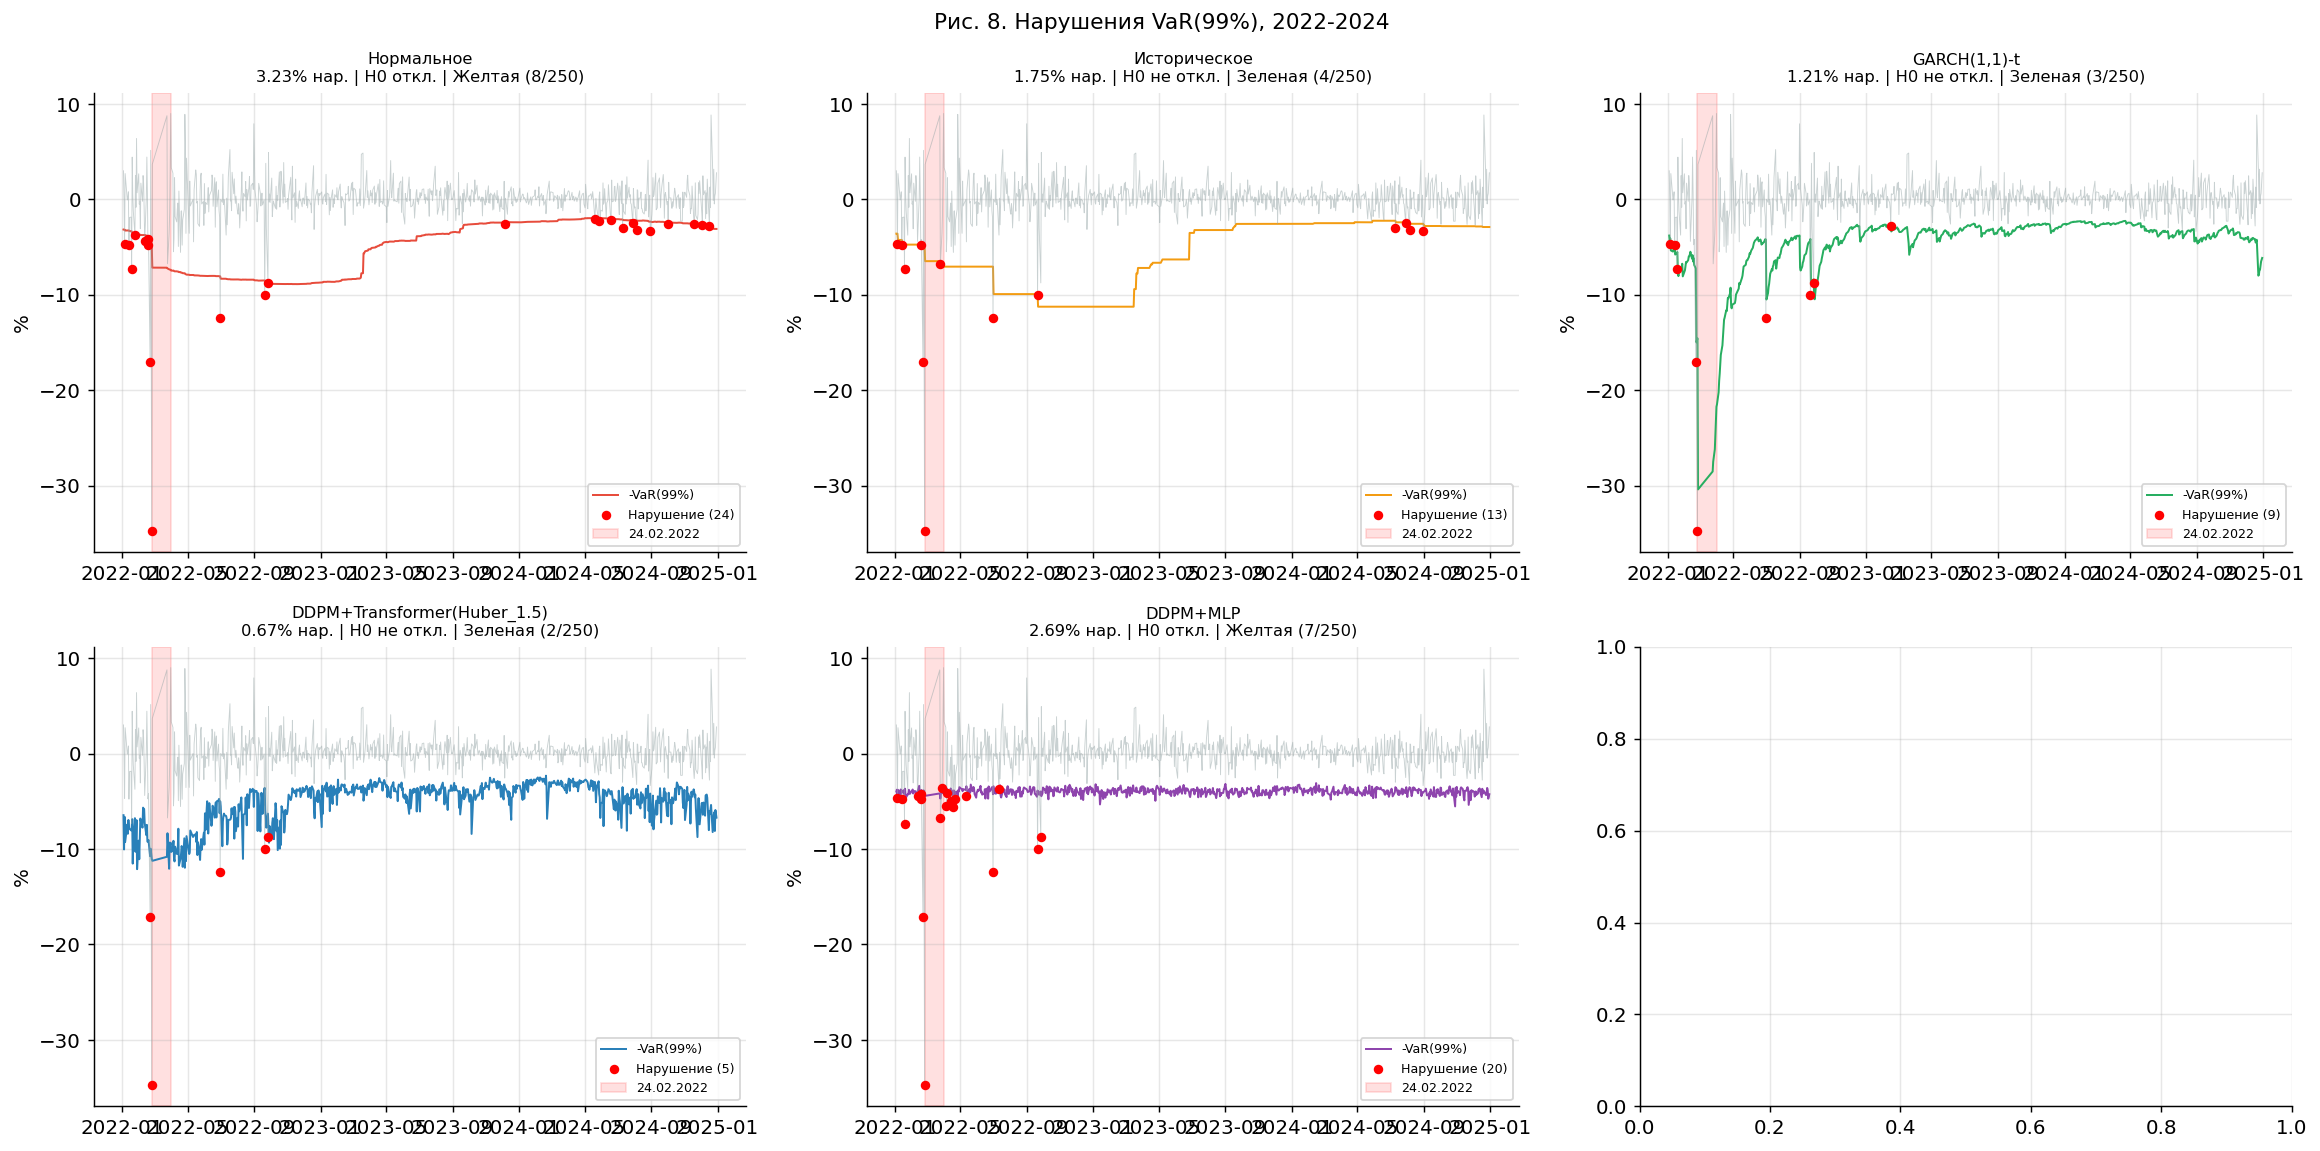

Рис. 8 сохранён


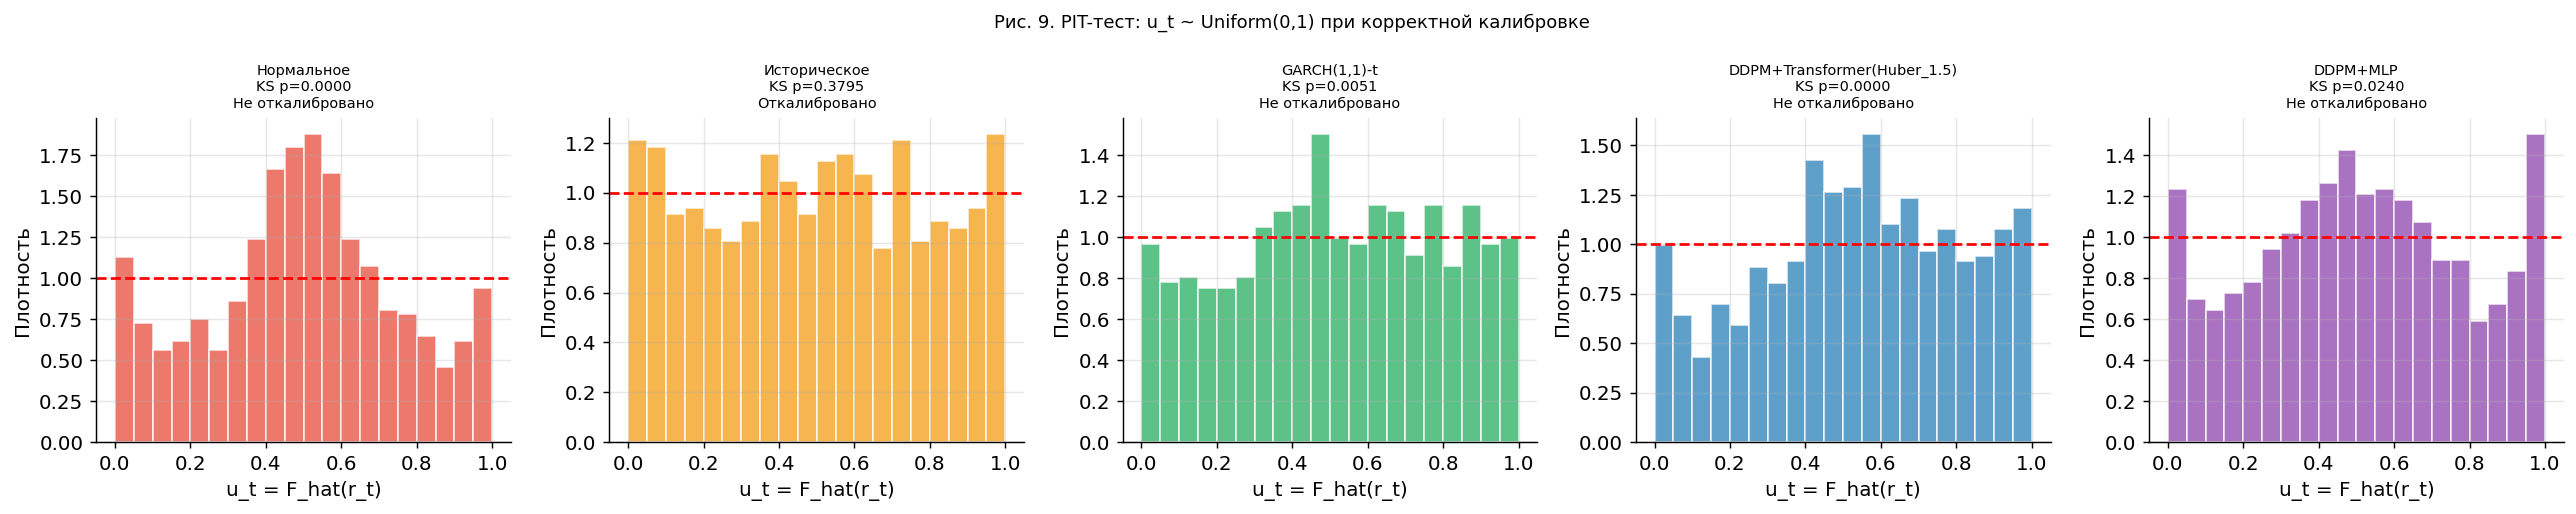

Рис. 9 сохранён


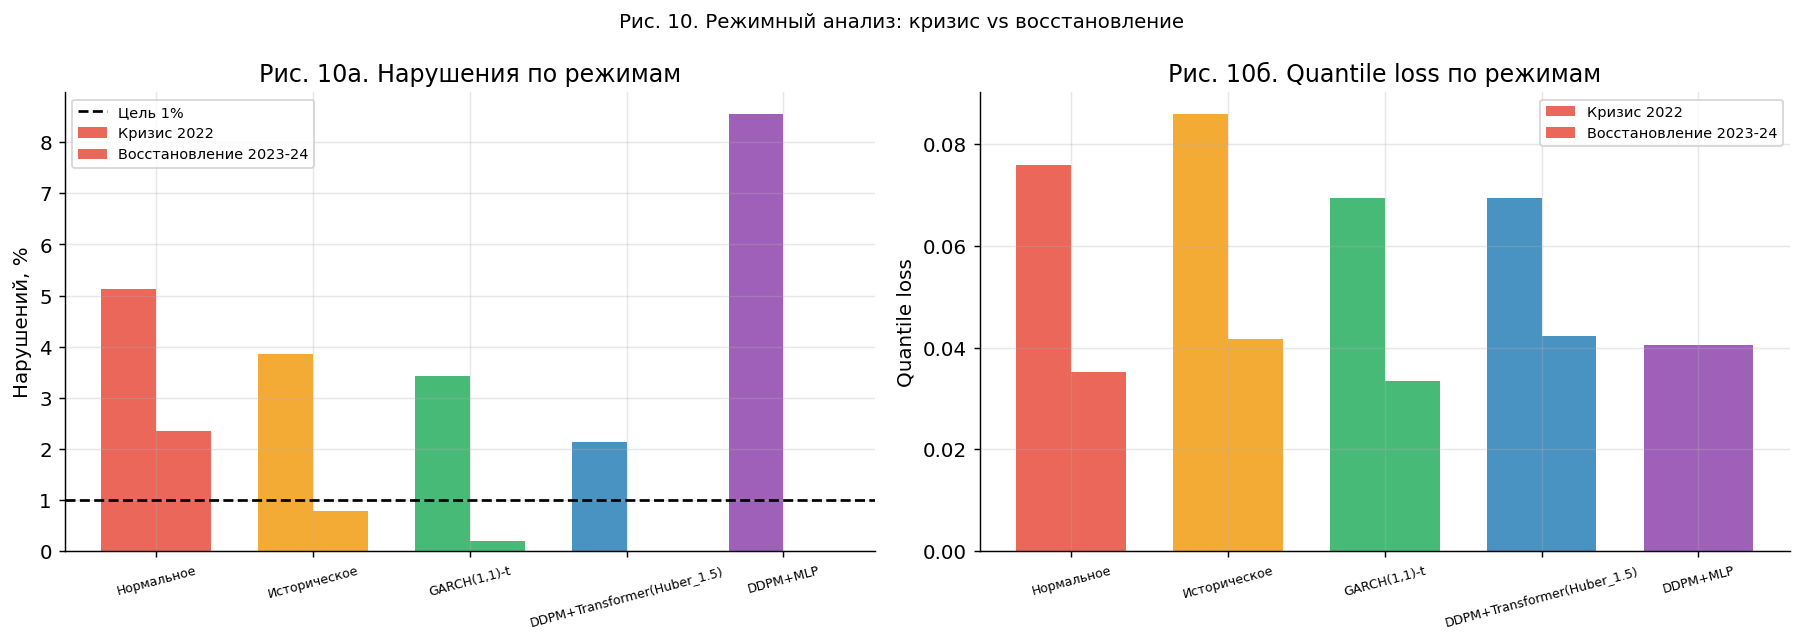

Рис. 10 сохранён

VaR-оценки на 23.02.2022:
  Нормальное                    : -VaR = -4.75%
  Историческое                  : -VaR = -5.18%
  GARCH(1,1)-t                  : -VaR = -14.98%
  DDPM+Transformer(Huber_1.5)   : -VaR = -9.97%
  DDPM+MLP                      : -VaR = -3.85%
  Реализованный убыток: -34.78%


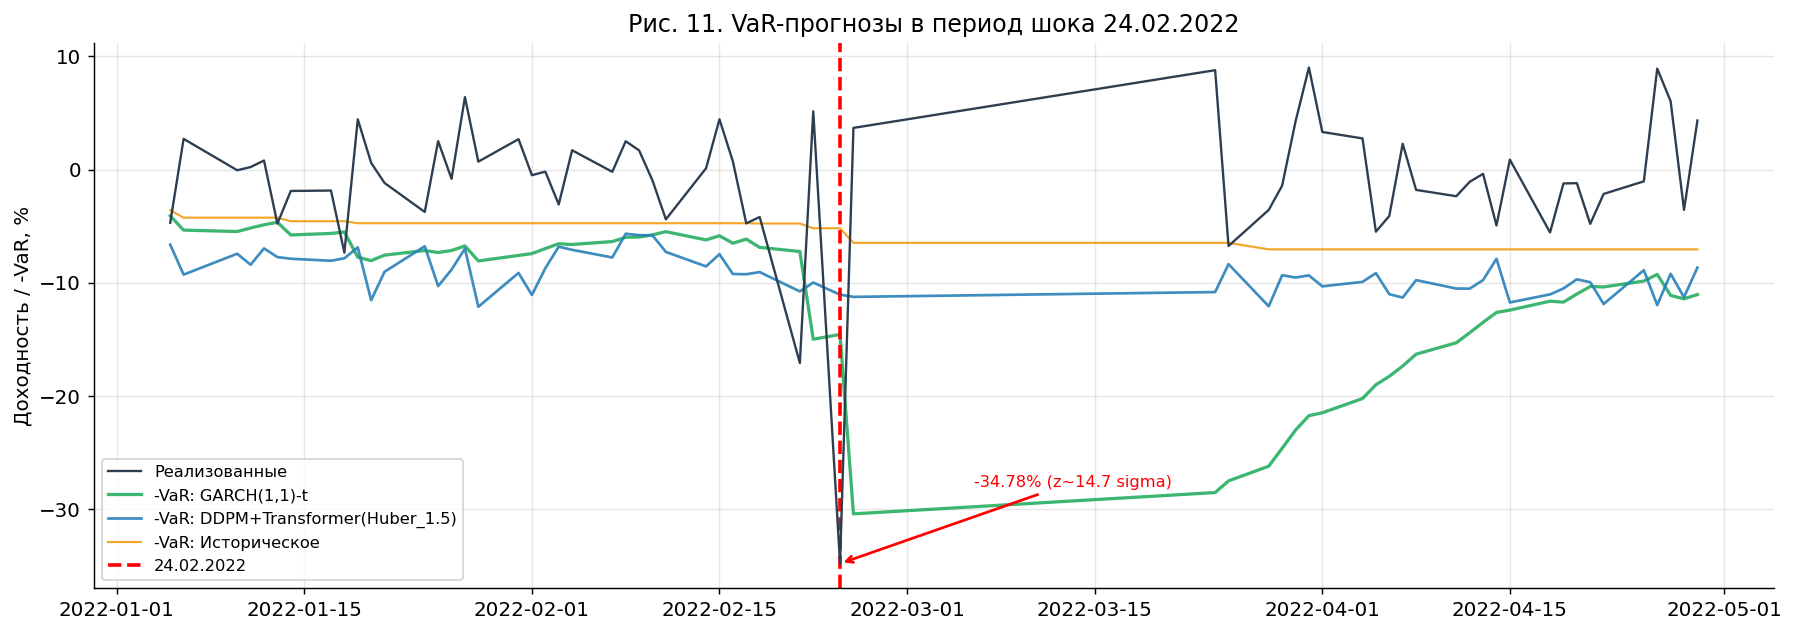

Рис. 11 сохранён


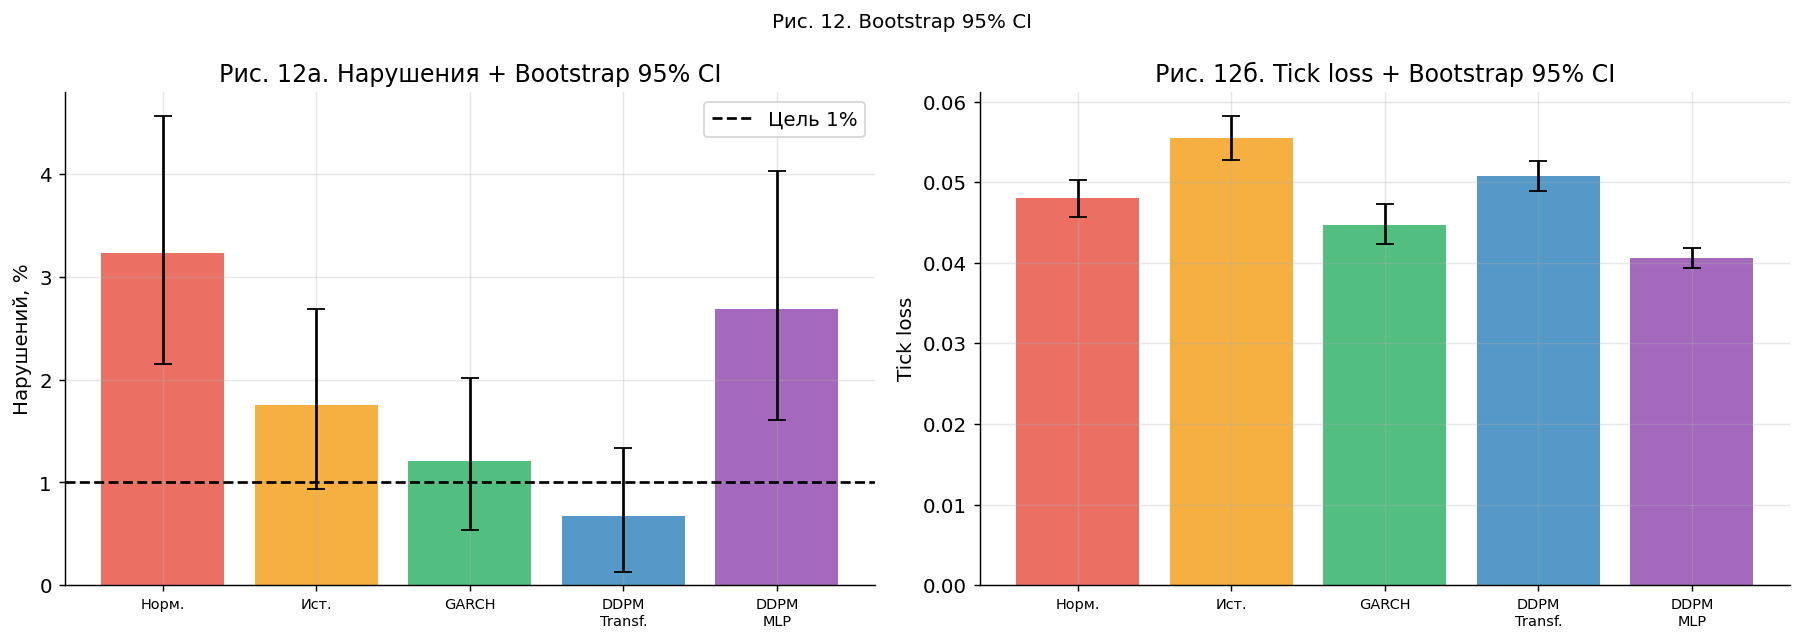

Рис. 12 сохранён

Все рисунки сохранены в figures/


In [31]:
# Визуализации

COLORS = {
    'normal':   '#E74C3C',
    'hist':     '#F39C12',
    'garch':    '#27AE60',
    'ddpm_tr':  '#2980B9',
    'ddpm_mlp': '#8E44AD',
    'actual':   '#2C3E50',
}
STRESS_START = pd.Timestamp('2022-02-24')
STRESS_END   = pd.Timestamp('2022-04-01')

def shade_stress(ax):
    ax.axvspan(STRESS_START, STRESS_END, color='red', alpha=0.12, label='24.02.2022')

# Рисунок 1. Временной ряд и скользящая волатильность
fig, axes = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [2, 1]})
ax = axes[0]
ax.plot(train_s.index, train_s.values*100, lw=0.7, color=COLORS['actual'], label='Train 2015-2021')
ax.plot(test_s.index,  test_s.values*100,  lw=0.7, color='#C0392B',        label='Test 2022-2024')
ax.axvspan(pd.Timestamp('2020-01-20'), pd.Timestamp('2020-04-01'), color='orange', alpha=0.12, label='COVID-19 2020')
shade_stress(ax)
ax.set_ylabel('Доходность, %'); ax.legend(fontsize=9, ncol=4)
ax.set_title('Рис. 1. Дневные доходности портфеля SBER/LKOH/GAZP (total return)')
ax2 = axes[1]
roll = portfolio_returns.rolling(30).std() * 100
ax2.fill_between(roll.index, roll.values, alpha=0.5, color=COLORS['ddpm_tr'], label='Rolling sigma (30 дн.)')
shade_stress(ax2)
ax2.set_ylabel('sigma, %'); ax2.legend(fontsize=9)
ax2.set_title('Скользящая волатильность (30 дней)')
plt.tight_layout()
plt.savefig('figures/fig01_returns.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 1 сохранён')

# Рисунок 2. Эмпирическое распределение vs нормальное, QQ-plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(train_arr*100, bins=70, density=True, color=COLORS['actual'], alpha=0.65, label='Эмпирическое (train)')
xr = np.linspace(train_arr.min()*100, train_arr.max()*100, 300)
ax.plot(xr, stats.norm.pdf(xr, train_arr.mean()*100, train_arr.std()*100), 'r-', lw=2, label='N(mu, sigma^2)')
ax.set_xlabel('Доходность, %'); ax.set_ylabel('Плотность')
ax.set_title(f'Рис. 2а. Эмпирическое vs нормальное (Kurt={stats.kurtosis(train_arr):.2f})')
ax.legend()
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(train_arr, dist='norm', fit=True)
ax.scatter(osm, osr, s=5, alpha=0.5, color=COLORS['actual'])
xq = np.array([min(osm), max(osm)])
ax.plot(xq, slope*xq + intercept, 'r-', lw=2, label='N(0,1)')
ax.set_xlabel('Теоретические квантили'); ax.set_ylabel('Эмпирические квантили')
ax.set_title('Рис. 2б. QQ-plot'); ax.legend()
plt.tight_layout()
plt.savefig('figures/fig02_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 2 сохранён')

# Рисунок 3. ACF доходностей и квадратов доходностей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_arr,    lags=40, ax=axes[0], zero=False, title='Рис. 3а. ACF r_t')
plot_acf(train_arr**2, lags=40, ax=axes[1], zero=False, title='Рис. 3б. ACF r^2_t (ARCH-эффект)')
plt.tight_layout()
plt.savefig('figures/fig03_acf.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 3 сохранён')

# Рисунок 4. Кривые обучения
if any(training_history.get(k) is not None for k in ['tr_huber15', 'mlp_mse']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, key, title in zip(axes, ['tr_huber15', 'mlp_mse'],
                               ['Transformer(Huber(1.5))', 'MLP(MSE) — ablation']):
        hist = training_history.get(key)
        if hist is None:
            ax.text(0.5, 0.5, 'Загружен из чекпоинта', ha='center', va='center',
                    transform=ax.transAxes); ax.set_title(title); continue
        ep = range(1, len(hist['train']) + 1)
        ax.plot(ep, hist['train'], label='Train MSE', color='#2980B9', lw=1.2)
        ax.plot(ep, hist['val'],   label='Val MSE',   color='#27AE60', lw=1.2)
        bv, be = hist['best_val'], hist['best_epoch']
        ax.axhline(bv, color='red', ls='--', lw=0.8, label=f'Best={bv:.4f} (ep={be})')
        ax.axvline(be, color='gray', ls=':', lw=0.8)
        ax.set_xlabel('Эпоха'); ax.set_ylabel('MSE'); ax.legend(fontsize=8); ax.set_title(f'Рис. 4. {title}')
    plt.tight_layout()
    plt.savefig('figures/fig04_training.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Рис. 4 сохранён')

# Рисунок 4б. Ablation B: val_MSE по конфигурациям
fig, ax = plt.subplots(figsize=(10, 4))
labels_b = ['MSE', 'Huber(d=0.5)', 'Huber(d=1.5)', 'Huber(d=2.5)']
vals_b   = [0.4245, 0.3952, 0.4243, 0.4335]
colors_b = ['#95A5A6', '#2980B9', '#BDC3C7', '#BDC3C7']
bars = ax.bar(labels_b, vals_b, color=colors_b, alpha=0.85, width=0.6)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.axhline(0.4245, color='gray', ls='--', lw=1, label='MSE baseline')
ax.set_ylabel('Val MSE'); ax.set_title('Рис. 4б. Ablation B: функция потерь денойзера')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig04b_ablation_loss.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 4б сохранён')

# Рисунок 5. Распределение сценариев DDPM vs реальные данные
ctx_last  = train_arr[-W:]
scen_show = generate_scenarios(ctx_last, trained_models['tr_huber05'], n=3000)
fig, ax   = plt.subplots(figsize=(12, 5))
ax.hist(train_arr*100, bins=80, density=True, color='#BDC3C7', alpha=0.8, label='Реальные (train)')
ax.hist(scen_show*100, bins=80, density=True, color=COLORS['ddpm_tr'], alpha=0.5, label='DDPM (3000 сценариев)')
xr = np.linspace(min(train_arr.min(), scen_show.min())*100, max(train_arr.max(), scen_show.max())*100, 300)
ax.plot(xr, stats.norm.pdf(xr, train_arr.mean()*100, train_arr.std()*100), 'r-', lw=2, label='N(mu, sigma^2)')
v_sc = float(np.quantile(-scen_show, ALPHA)); v_no, _ = var_cvar_normal(train_arr)
ax.axvline(-v_sc*100, color=COLORS['ddpm_tr'], ls='--', lw=2, label=f'VaR DDPM={v_sc*100:.2f}%')
ax.axvline(-v_no*100, color='red',             ls='--', lw=2, label=f'VaR Normal={v_no*100:.2f}%')
ax.set_xlabel('Доходность, %'); ax.set_ylabel('Плотность')
ax.set_title(f'Рис. 5. DDPM vs реальные vs нормальное '
             f'(kurt={stats.kurtosis(scen_show):.2f}, std={scen_show.std()*100:.3f}%)')
ax.set_xlim(-15, 12); ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('figures/fig05_scenarios.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 5 сохранён')

# Рисунок 6. Fan Chart — условное распределение DDPM во времени
print('Генерация Fan Chart...')
FAN_STEP = 5; fan_pctls = [1, 5, 25, 75, 95, 99]
fan_dates, fan_actual = [], []; fan_q = {p: [] for p in fan_pctls}
for i in range(0, n_test, FAN_STEP):
    idx   = n_train + i
    ctx_w = all_arr[max(0, idx - W): idx]
    if len(ctx_w) < W:
        ctx_w = np.pad(ctx_w, (W - len(ctx_w), 0), mode='edge')
    scen = generate_scenarios(ctx_w, trained_models['tr_huber05'], n=500)
    fan_dates.append(test_s.index[i]); fan_actual.append(all_arr[idx] * 100)
    for p in fan_pctls:
        fan_q[p].append(float(np.percentile(scen * 100, p)))
fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(fan_dates, fan_q[1],  fan_q[99],  alpha=0.12, color=COLORS['ddpm_tr'], label='1-99 перцентиль')
ax.fill_between(fan_dates, fan_q[5],  fan_q[95],  alpha=0.22, color=COLORS['ddpm_tr'], label='5-95 перцентиль')
ax.fill_between(fan_dates, fan_q[25], fan_q[75],  alpha=0.38, color=COLORS['ddpm_tr'], label='25-75 перцентиль')
ax.plot(fan_dates, fan_q[1],  color=COLORS['ddpm_tr'], lw=0.7, ls='--', alpha=0.6)
ax.plot(fan_dates, fan_q[99], color=COLORS['ddpm_tr'], lw=0.7, ls='--', alpha=0.6)
ax.scatter(fan_dates, fan_actual, s=7, color=COLORS['actual'], zorder=5, label='Реализованные', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, alpha=0.5); shade_stress(ax)
ax.set_ylabel('Доходность, %')
ax.set_title('Рис. 6. Fan Chart: условное распределение DDPM+Transformer(Huber(0.5))')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('figures/fig06_fanchart.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 6 сохранён')

# Рисунок 7. VaR бэктест — все модели
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_s.index, test_arr*100, color=COLORS['actual'], lw=0.7, alpha=0.9, label='Реализованные', zorder=3)
for key in ['normal', 'hist', 'garch']:
    idx_l = results[key]['idx']
    ax.plot(test_s.index[idx_l], -np.array(results[key]['var'])*100,
            lw=1.3, color=COLORS[key], alpha=0.8, label=f'-VaR: {NAMES[key]}')
idx_d = results['ddpm_tr']['idx']
ax.scatter(test_s.index[idx_d[::3]], -np.array(results['ddpm_tr']['var'])[::3]*100,
           s=8, color=COLORS['ddpm_tr'], zorder=4, alpha=0.7, label=f'-VaR: {NAMES["ddpm_tr"]}')
shade_stress(ax); ax.set_ylabel('Доходность / -VaR, %')
ax.set_title('Рис. 7. Бэктест VaR(99%), 2022-2024'); ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig('figures/fig07_backtest.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 7 сохранён')

# Рисунок 8. Нарушения VaR по моделям (сетка 2x3)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, key in zip(axes.flat, list(NAMES.keys())):
    idx_l  = results[key]['idx']; var_l = np.array(results[key]['var'])
    act_l  = test_arr[idx_l];     dates_ = test_s.index[idx_l]; viols = (-act_l > var_l)
    m      = metrics[key]
    ax.plot(dates_, -var_l*100, color=COLORS[key], lw=1.1, label='-VaR(99%)')
    ax.plot(dates_,  act_l*100, color='#95A5A6',   lw=0.5, alpha=0.5)
    ax.scatter(dates_[viols], act_l[viols]*100, color='red', s=18, zorder=5,
               label=f'Нарушение ({viols.sum()})')
    shade_stress(ax)
    ax.set_title(f'{m["name"]}\n{m["viol_pct"]}% нар. | {m["kup_v"]} | {m["basel"]}', fontsize=9)
    ax.set_ylabel('%'); ax.legend(fontsize=7)
plt.suptitle('Рис. 8. Нарушения VaR(99%), 2022-2024', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig08_violations.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 8 сохранён')

# Рисунок 9. PIT-гистограммы
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, key in zip(axes, NAMES.keys()):
    pit_a   = np.array(results[key]['pit'])
    _, ks_p = stats.kstest(pit_a, 'uniform')
    verdict = 'Откалибровано' if ks_p > 0.05 else 'Не откалибровано'
    ax.hist(pit_a, bins=20, density=True, color=COLORS[key], alpha=0.75, edgecolor='white')
    ax.axhline(1.0, color='red', ls='--', lw=1.5)
    ax.set_xlabel('u_t = F_hat(r_t)'); ax.set_ylabel('Плотность')
    ax.set_title(f'{NAMES[key]}\nKS p={ks_p:.4f}\n{verdict}', fontsize=8)
plt.suptitle('Рис. 9. PIT-тест: u_t ~ Uniform(0,1) при корректной калибровке', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig09_pit.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 9 сохранён')

# Рисунок 10. Режимный анализ
regime_df = pd.read_csv('results/table5_regime.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = [NAMES[k] for k in NAMES]; colors_l = [COLORS[k] for k in NAMES]
x = np.arange(5); w = 0.35
for col_idx, data_key in enumerate(['Кризис 2022', 'Восстановление 2023-24']):
    rdf = regime_df[regime_df['Период'] == data_key]
    if rdf.empty: continue
    pos   = x - w/2 if col_idx == 0 else x + w/2
    label = data_key
    axes[0].bar(pos, rdf['Нар.,%'].values, w, label=label, color=colors_l if col_idx==0
                else [c+'AA' for c in colors_l], alpha=0.85)
    axes[1].bar(pos, rdf['Tick'].values, w, label=label, color=colors_l if col_idx==0
                else [c+'AA' for c in colors_l], alpha=0.85)
axes[0].axhline(1.0, color='black', ls='--', lw=1.5, label='Цель 1%')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels, fontsize=7, rotation=15)
axes[0].set_ylabel('Нарушений, %'); axes[0].set_title('Рис. 10а. Нарушения по режимам'); axes[0].legend(fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_labels, fontsize=7, rotation=15)
axes[1].set_ylabel('Quantile loss'); axes[1].set_title('Рис. 10б. Quantile loss по режимам'); axes[1].legend(fontsize=8)
plt.suptitle('Рис. 10. Режимный анализ: кризис vs восстановление', fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig10_regime.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 10 сохранён')

# Рисунок 11. Зум на период шока 24.02.2022
zoom_mask = (test_s.index >= '2022-01-05') & (test_s.index <= '2022-05-01')
zoom_idx  = np.where(zoom_mask)[0]
fig, ax   = plt.subplots(figsize=(14, 5))
ax.plot(test_s.index[zoom_mask], test_arr[zoom_idx]*100,
        color=COLORS['actual'], lw=1.3, label='Реализованные', zorder=5)
for key, lw_ in [('garch', 1.8), ('ddpm_tr', 1.5), ('hist', 1.2)]:
    idx_l = np.array(results[key]['idx']); cmn = np.intersect1d(idx_l, zoom_idx)
    if len(cmn) == 0: continue
    pos = [np.where(idx_l==c)[0][0] for c in cmn]
    ax.plot(test_s.index[cmn], -np.array(results[key]['var'])[pos]*100,
            color=COLORS[key], lw=lw_, alpha=0.9, label=f'-VaR: {NAMES[key]}')
ax.axvline(STRESS_START, color='red', ls='--', lw=2, label='24.02.2022')
ax.annotate('-34.78% (z~14.7 sigma)',
            xy=(STRESS_START, -34.78), xytext=(STRESS_START + pd.Timedelta(days=10), -28),
            fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_ylabel('Доходность / -VaR, %')
ax.set_title('Рис. 11. VaR-прогнозы в период шока 24.02.2022')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig11_stress_zoom.png', dpi=150, bbox_inches='tight')
print('\nVaR-оценки на 23.02.2022:')
pre_shock = pd.Timestamp('2022-02-23')
for key in NAMES:
    idx_l   = np.array(results[key]['idx']); var_arr = np.array(results[key]['var'])
    dists   = np.abs((test_s.index[idx_l] - pre_shock).total_seconds().values)
    near    = np.argmin(dists)
    print(f'  {NAMES[key]:30s}: -VaR = {-var_arr[near]*100:.2f}%')
print(f'  Реализованный убыток: -34.78%')
plt.show(); print('Рис. 11 сохранён')

# Рисунок 12. Bootstrap CI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_labels = ['Норм.', 'Ист.', 'GARCH', 'DDPM\nTransf.', 'DDPM\nMLP']
colors_list  = [COLORS[k] for k in NAMES]
viol_v  = [metrics[k]['viol_pct']     for k in NAMES]
viol_lo = [metrics[k]['viol_ci'][0]   for k in NAMES]
viol_hi = [metrics[k]['viol_ci'][1]   for k in NAMES]
axes[0].bar(range(5), viol_v, color=colors_list, alpha=0.8)
axes[0].errorbar(range(5), viol_v,
                 yerr=[[v-lo for v,lo in zip(viol_v,viol_lo)],
                       [hi-v for v,hi in zip(viol_v,viol_hi)]],
                 fmt='none', color='black', capsize=5, lw=1.5)
axes[0].axhline(1.0, color='black', ls='--', lw=1.5, label='Цель 1%')
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(short_labels, fontsize=8)
axes[0].set_ylabel('Нарушений, %'); axes[0].set_title('Рис. 12а. Нарушения + Bootstrap 95% CI'); axes[0].legend()
tick_v  = [metrics[k]['tick']       for k in NAMES]
tick_lo = [metrics[k]['tick_ci'][0] for k in NAMES]
tick_hi = [metrics[k]['tick_ci'][1] for k in NAMES]
axes[1].bar(range(5), tick_v, color=colors_list, alpha=0.8)
axes[1].errorbar(range(5), tick_v,
                 yerr=[[v-lo for v,lo in zip(tick_v,tick_lo)],
                       [hi-v for v,hi in zip(tick_v,tick_hi)]],
                 fmt='none', color='black', capsize=5, lw=1.5)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(short_labels, fontsize=8)
axes[1].set_ylabel('Tick loss'); axes[1].set_title('Рис. 12б. Tick loss + Bootstrap 95% CI')
plt.suptitle('Рис. 12. Bootstrap 95% CI', fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig12_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Рис. 12 сохранён')
print('\nВсе рисунки сохранены в figures/')

In [32]:
# Итоговое резюме

print()
print('Итоговые результаты')
print()

tr_m  = metrics['ddpm_tr'];  mlp_m = metrics['ddpm_mlp']
g_m   = metrics['garch'];    n_m   = metrics['normal']

print(f'\nОсновной бэктест (N={tr_m["n_obs"]} наблюдений, 2022-2024):')
print(f'  {"Модель":<35} {"Нар.,%":>7} {"Купик":>12} {"Basel":>22} {"Tick":>8} {"CRPS":>8}')
print(f'  {"-"*95}')
for key, m in metrics.items():
    print(f'  {m["name"]:<35} {m["viol_pct"]:>7.2f} {m["kup_v"]:>12} '
          f'{m["basel"]:>22} {m["tick"]:>8.5f} {m["crps"]:>8.5f}')

print(f'\nDM-тест Transformer vs GARCH:')
dm_tr_g = diebold_mariano_test(test_arr[results['ddpm_tr']['idx']],
                                np.array(results['ddpm_tr']['var']),
                                np.array(results['garch']['var']))
print(f'  DM={dm_tr_g["DM_stat"]}, p={dm_tr_g["p_value"]}, {dm_tr_g["verdict"]}, лучше: {dm_tr_g["better"]}')

print(f'\nDM-тест Transformer vs MLP:')
dm_tr_m = diebold_mariano_test(test_arr[results['ddpm_tr']['idx']],
                                np.array(results['ddpm_tr']['var']),
                                np.array(results['ddpm_mlp']['var']))
print(f'  DM={dm_tr_m["DM_stat"]}, p={dm_tr_m["p_value"]}, {dm_tr_m["verdict"]}, лучше: {dm_tr_m["better"]}')

print(f'Ablation B (val_MSE): MSE={vm_mse:.5f}, Huber(d=0.5)={vm_h05:.5f} '
      f'(delta={_delta(vm_h05):+.1f}%), Huber(d=1.5)={vm_h15:.5f} '
      f'(delta={_delta(vm_h15):+.1f}%)')
print(f'\nСохранённые файлы:')
for path in ['results/table2_descriptive.csv', 'results/table3_backtest.csv',
             'results/table4a_ablation_arch.csv', 'results/table4b_ablation_loss.csv',
             'results/table5_regime.csv', 'results/table6_dm_test.csv']:
    status = 'OK' if os.path.exists(path) else 'НЕ НАЙДЕН'
    print(f'  [{status}] {path}')
print('  Рисунки: figures/fig01_returns.png ... figures/fig12_bootstrap.png')


Итоговые результаты


Основной бэктест (N=744 наблюдений, 2022-2024):
  Модель                               Нар.,%        Купик                  Basel     Tick     CRPS
  -----------------------------------------------------------------------------------------------
  Нормальное                             3.23     H0 откл.         Желтая (8/250)  0.04800  0.01040
  Историческое                           1.75  H0 не откл.        Зеленая (4/250)  0.05552  0.00988
  GARCH(1,1)-t                           1.21  H0 не откл.        Зеленая (3/250)  0.04475  0.00949
  DDPM+Transformer(Huber_1.5)            0.67  H0 не откл.        Зеленая (2/250)  0.05080  0.00966
  DDPM+MLP                               2.69     H0 откл.         Желтая (7/250)  0.04054  0.00987

DM-тест Transformer vs GARCH:
  DM=7.3622, p=0.0, Значимо, лучше: B

DM-тест Transformer vs MLP:
  DM=13.6525, p=0.0, Значимо, лучше: B
Ablation B (val_MSE): MSE=0.37235, Huber(d=0.5)=0.37591 (delta=+1.0%), Huber(d=1.5)=0.33253 (d